# NB10a: Dietrich 2025 Paper Replication v7 (faithful + Optuna on faithful protocol)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


Strict paper-faithful Dietrich 2025 replication on V3 per-pixel data with
GroupKFold by city across 21 UNOSAT-labelled Ukrainian cities. Mirrors
NB10b v10's structure (faithful first, then Optuna on the same protocol).

## In scope (this notebook)

| Cell | Method | Sampling unit | Trial budget |
|---|---|---|---|
| C2 | Faithful Dietrich RF-50 (28 features) | V3 + 3x3 max | -- |
| C2.5a | Spatial proximity audit (V3 building density diagnostic) | V3 | -- |
| C2.5b | Date-aware Eq.1 label expansion (paper extension) | V3 | -- |
| C3 | Optuna RF on Dietrich's V3 protocol (3a 4/14 split, 3b GroupKFold) | V3 + 3x3 max | 200 / sub |
| C7 | Per-city AUC distribution + bootstrap leakage CI | -- | -- |
| C8 | Save consolidated OOF + summary | -- | -- |

Every B-cell saves OOF parquets via `save_oof_from_result()` and
registers in the experiment registry via `log_result()` (which calls
`registry.log_experiment` internally).

## Out of scope (-> NB11a v2)

- C2e -- V2 building-footprint Dietrich-28 (different sampling unit)
- C4 -- Alternative classifiers (XGBoost / LightGBM / ExtraTrees) on
  Dietrich's V3 protocol
- C5 -- V4 (3x3 kernel parquet) shortcut
- C6 -- V4 ceiling: best classifier x richer features

## Architecture symmetry with NB10b v10

| | NB10a v7 | NB10b v10 |
|---|---|---|
| Faithful baseline | C2 (RF-50 paper params) | B1, B2, B3a, B5 (paper params) |
| Optuna on same protocol | C3 (RF-Optuna 200) | B2_Optuna (200/pol), B5_Optuna (200/clf) |

Both notebooks: paper as published, then paper's method tuned. Modality
variants and best-of-category live in NB11 series.

In [1]:
# @title CELL 3: NB10a CONFIG
TIER_SELECTION = [0,1,2]
CITY_FILTER = None
CITY_SELECTION = None
REQUIRE_UNOSAT = True
RANDOM_STATE = 42
N_FOLDS = 5

# v2 parquet system (manifest-driven). Set to False to fall back to v1 paths.
USE_V2 = True

# --- NB10a: Dietrich paper replication-specific config ---
# Dietrich's 4-train / 14-test geographic split (paper p.7)
DIETRICH_TRAIN_CITIES = ['Mariupol', 'Lysychansk', 'Sievierodonetsk', 'Rubizhne']
# Test cities = all UNOSAT cities NOT in train list (resolved at runtime)

# Dietrich paper RF hyperparameters (paper p.8)
RF_DIETRICH_PARAMS = {
    'n_estimators': 50,            # Dietrich: 50 decision trees
    'min_samples_leaf': 3,         # Dietrich: minLeafPopulation = 3
    'max_leaf_nodes': 10000,       # Dietrich: maxNodes = 10000
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'class_weight': 'balanced',
}

# Optuna budget per cell (override per-experiment if needed)
OPTUNA_TRIALS_FAITHFUL  = 200   # C3 — headline number, larger budget
OPTUNA_TRIALS_BEST_OTHER = 200  # C4/C5/C6 — standard budget
OPTUNA_TRIALS_CEILING    = 200  # C6 best-of-best


In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os, json
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())

BDA GLOBAL SETUP
Started: 2026-05-07 23:43:03
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     910.9/7452.0 GB (6541.1 GB free)
  GDrive (F:)     1408.1/3726.0 GB (2317.9 GB free)
  Local data      11559.5/14901.9 GB (3342.4 GB free)
  Data stack      1408.1/3726.0 GB (2317.9 GB free)
  WSL ext4        68.6/1006.9 GB (887.1 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL S0: LOAD MANIFEST + BUILDINGS + SHARED HELPERSLoads v2 parquet manifest, building metadata, defines `load_v2()` loader that readsone parquet per call with columns filter, merges with buildings. Every downstreamR-cell calls `load_v2(manifest_key)` then does `del df; gc.collect()` at end.

In [3]:
# @title CELL S0: LOAD MANIFEST + POINTS + SHARED HELPERS
import sys, importlib, re, gc, time
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, precision_recall_curve, roc_curve)
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("CELL S0: NB10a v1 — LOAD V3 + V4 + V2-FOOTPRINT MANIFESTS + SHARED HELPERS")
print("=" * 70)

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

# --- load V4 manifest -------------------------------------------------
# V4 dataset path (not in global_setup.py which only defines V2)
DATASET_ROOT_V4 = STACK_DIR / 'dataset' / 'v4'
MANIFEST_V4_PATH = DATASET_ROOT_V4 / 'parquet_manifest.json'
if not MANIFEST_V4_PATH.exists():
    raise FileNotFoundError(f"V4 manifest not found: {MANIFEST_V4_PATH}")
with open(MANIFEST_V4_PATH) as _f:
    MANIFEST = json.load(_f)
print(f"  Manifest: {MANIFEST_V4_PATH}")
print(f"  Version: {MANIFEST['version']}  Created: {MANIFEST['created']}")
print(f"  Parquets in manifest: {len(MANIFEST['parquets'])}")

# --- load point metadata (V4 path) --------------------------------
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
_bldg_pattern = str(DATASET_ROOT_V4 / 'bda_points_t{tier}.parquet')
df_bldg = load_tier_parquets(_bldg_pattern, _tiers)
CITIES_TO_PROCESS, _battle_dates = resolve_cities(
    tier_selection=TIER_SELECTION,
    city_selection=[CITY_FILTER] if isinstance(CITY_FILTER, str) else CITY_FILTER,
    require_unosat=REQUIRE_UNOSAT,
)
df_bldg = df_bldg[df_bldg['city'].isin(CITIES_TO_PROCESS)].copy()
df_bldg = df_bldg[df_bldg['damage_binary'] >= 0].copy()
print(f"  Cities: {len(CITIES_TO_PROCESS)}")
print(f"  Points: {len(df_bldg)} (damaged={int((df_bldg['damage_binary']==1).sum())}, undamaged={int((df_bldg['damage_binary']==0).sum())})")

TARGET_COL = 'damage_binary'
EXPERIMENT_LOG = {}
DIETRICH_PAPER = {'auc': 0.813, 'f1': 0.749, 'precision': 0.671, 'recall': 0.846}

# ---- NB12 overlap-analysis: canonical OOF predictions schema ----
import hashlib as _hashlib, datetime as _dt
EXPERIMENT_ID = _dt.datetime.now().strftime('%Y%m%d_%H%M%S') + '_' + _hashlib.md5(
    f'nb09a_{TIER_SELECTION}_{REQUIRE_UNOSAT}'.encode()).hexdigest()[:6]
print(f"  EXPERIMENT_ID: {EXPERIMENT_ID}")

def save_oof_from_result(res, model_id, oof_dir, variant_id='',
                         is_final=False, threshold=0.5):
    '''Canonical OOF schema from a result dict that contains:
       y_true, y_proba, groups, building_id, fold_id (all same length, valid-masked).'''
    if res is None:
        return None
    needed = ('y_true', 'y_proba', 'groups', 'point_id', 'fold_id')
    if not all(k in res for k in needed):
        print(f"    [save_oof] skipped {model_id}: missing keys (need {needed})")
        return None
    y_proba = np.asarray(res['y_proba'])
    yt = np.asarray(res['y_true']).astype(int)
    fold = np.asarray(res['fold_id']).astype(int)
    bid = np.asarray(res['point_id'])
    cty = np.asarray(res['groups'])
    yp = (y_proba >= threshold).astype(int)
    cm_class = np.where(yt == 1,
                        np.where(yp == 1, 'TP', 'FN'),
                        np.where(yp == 1, 'FP', 'TN'))
    oof_df = pd.DataFrame({
        'point_id':   bid,
        'city':          cty,
        'fold_id':       fold,
        'y_true':        yt,
        'y_proba':       y_proba.astype(float),
        'y_pred':        yp,
        'cm_class':      cm_class,
        'model_id':      model_id,
        'experiment_id': EXPERIMENT_ID,
        'variant_id':    variant_id,
        'is_final':      bool(is_final),
    })
    oof_dir = Path(oof_dir)
    oof_dir.mkdir(parents=True, exist_ok=True)
    out = oof_dir / f'oof_{model_id}__{EXPERIMENT_ID}.parquet'
    oof_df.to_parquet(out, index=False)
    n_tp = int((cm_class == 'TP').sum()); n_fn = int((cm_class == 'FN').sum())
    n_fp = int((cm_class == 'FP').sum()); n_tn = int((cm_class == 'TN').sum())
    print(f"    saved oof -> {out.name}  TP={n_tp} FN={n_fn} FP={n_fp} TN={n_tn}")
    return out

# --- metadata filter: single source of truth for leakage exclusion ----
# Previous hardcoded LEAKAGE_EXCLUDE_PATTERNS (4 patterns) covered only a
# subset of leakage vectors -- missing was_observed_*, s1__vv__scenes_observed,
# s2__scenes_observed, s2__lu__scenes_observed, s2__visibility__{fire,smoke,
# clear}__freq, block __count_*, rolling __count_*, and the full dietrich
# pixel-count family. metadata_filter.is_non_feature() catches all of them
# via pattern rules and a name-based metadata whitelist.
import importlib
import metadata_filter
importlib.reload(metadata_filter)
from metadata_filter import is_non_feature

def drop_leakage(cols):
    # Thin wrapper so existing prepare_features() and experiment cells keep
    # working. Strictly MORE restrictive than the old 4-pattern filter.
    return [c for c in cols if not is_non_feature(c)]

# --- Dietrich-28 stat filter (NOT a metadata leak filter) ------------
# Used by filter_dietrich28() to exclude the 'count' stat from the
# Dietrich-28 feature subset. Separate concern from metadata leakage:
# this is about matching Dietrich et al. 2025's replication spec.
EXCLUDE_CARD_STATS = ['count']

# --- dietrich column filter (from NB07 D1b, proven to work) ----------
def filter_dietrich28(cols):
    """Auto-detect column format and keep Dietrich's 7 backscatter stats.

    Stats kept: min, max, mean, median, std, kurtosis, skewness.
    Stats excluded: count (metadata) and accumulator stats (drop_count,
    rise_count, max_abs_delta, running_min, running_max).

    V2 footprint format: s1__{pol}__{block}__{stat}_{zonal_agg}
        e.g. s1__vh__blk01__std_mean (std temporal, mean zonal aggregation).
        Only zonal_agg='mean' is kept.

    V3 per-pixel and V4 3x3-kernel format: s1__{pol}__{block}__{stat}
        e.g. s1__vh__blk01__std (std only, no zonal aggregation).
        All 7 stats are kept directly.

    Note: prior versions of this function dropped 6 of 7 stats from V3 because
    the V2-style zonal_agg check was applied to V3 columns that have no zonal
    suffix. With V3 dietrich28 returning only ~38 columns instead of ~270,
    per-row feature richness was 14% of Dietrich's. Fix made on 2026-05-06.
    """
    DIETRICH_STATS = {'min', 'max', 'mean', 'median', 'std', 'kurtosis', 'skewness'}
    out = []
    for c in cols:
        parts = c.split('__')
        if len(parts) < 4:
            continue
        stat_agg = parts[3]
        if '_' in stat_agg:
            # V2 footprint: stat_temporal_stat_zonal
            stat_name, zonal_agg = stat_agg.rsplit('_', 1)
            if zonal_agg != 'mean':
                continue
        else:
            # V3 per-pixel or V4 3x3-kernel: single stat suffix, no zonal
            stat_name = stat_agg
        if stat_name not in DIETRICH_STATS:
            continue
        if stat_name in EXCLUDE_CARD_STATS:
            continue
        out.append(c)
    return out
def load_v2(manifest_key, tiers=None, columns=None, sample_frac=None):
    '''Load a v2 parquet by manifest key, merge with buildings, return df.'''
    if manifest_key not in MANIFEST['parquets']:
        raise KeyError(f"Manifest key not found: {manifest_key}")
    info = MANIFEST['parquets'][manifest_key]
    fname_tmpl = Path(info['pattern']).name
    tiers = tiers if tiers is not None else _tiers

    frames = []
    for t in tiers:
        pf = DATASET_ROOT_V4 / fname_tmpl.format(tier=t)
        if not pf.exists():
            print(f"  WARNING: {pf.name} not found, skipping tier {t}")
            continue
        if columns is not None:
            join_cols = info.get('join_keys', ['city', 'point_id'])
            read_cols = list(dict.fromkeys(join_cols + list(columns)))
            try:
                df_t = pd.read_parquet(pf, columns=read_cols)
            except Exception:
                df_t = pd.read_parquet(pf)
                keep = [c for c in read_cols if c in df_t.columns]
                df_t = df_t[keep]
        else:
            df_t = pd.read_parquet(pf)
        if sample_frac is not None and 0 < sample_frac < 1:
            df_t = df_t.sample(frac=sample_frac, random_state=RANDOM_STATE)
        frames.append(df_t)
    if not frames:
        raise FileNotFoundError(f"No v2 parquets found for key={manifest_key} tiers={tiers}")
    df = pd.concat(frames, ignore_index=True)
    del frames

    df = df.loc[:, ~df.columns.duplicated()]
    df = df[df['city'].isin(CITIES_TO_PROCESS)].copy()
    if TARGET_COL not in df.columns:
        df = df.merge(df_bldg[['point_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['point_id', 'city'], how='inner')
    df = df[df[TARGET_COL] >= 0].copy()
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"  load_v2('{manifest_key}'): {len(df):,} rows, {df.shape[1]} cols, {df['city'].nunique()} cities")
    return df

# --- legacy v1 loader kept intact (some cells may still use it) ------
def load_and_merge(parquet_fmt, **kwargs):
    """V1 loader: load per-tier v1 parquets by path fmt, merge with buildings."""
    if isinstance(parquet_fmt, Path) and parquet_fmt.exists():
        df = pd.read_parquet(parquet_fmt)
    else:
        df = load_tier_parquets(str(parquet_fmt), _tiers, **kwargs)
    df = df[df['city'].isin(CITIES_TO_PROCESS)].copy()
    if TARGET_COL not in df.columns:
        df = df.merge(df_bldg[['point_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['point_id', 'city'], how='inner')
    df = df[df[TARGET_COL] >= 0].copy()
    return df

# --- feature prep + evaluation helpers (unchanged from v20) ----------
def prepare_features(df, feat_cols, drop_all_nan=True):
    """Extract X, y, groups from df, drop all-NaN columns, median-impute."""
    feat_cols = [c for c in feat_cols if c in df.columns]
    feat_cols = drop_leakage(feat_cols)
    if not feat_cols:
        print(f"    SKIP: no non-leakage feature columns")
        return None
    if drop_all_nan:
        nan_rate = df[feat_cols].isna().mean()
        feat_cols = [c for c in feat_cols if nan_rate[c] < 1.0]
    if len(feat_cols) < 2:
        print(f"    SKIP: {len(feat_cols)} feature columns after NaN drop")
        return None
    X = df[feat_cols].values
    y = df[TARGET_COL].values
    groups = df['city'].values
    building_ids = df['point_id'].values
    imp = SimpleImputer(strategy='median')
    X = imp.fit_transform(X)
    return X, y, groups, building_ids, feat_cols


def evaluate_groupkfold(clf, X, y, groups, experiment_name, n_folds=N_FOLDS, needs_scaling=False,
                        building_ids=None):
    n_cities = len(np.unique(groups))
    n_folds_actual = min(n_folds, n_cities)
    if n_folds_actual < 2:
        print(f"    SKIP {experiment_name}: only {n_cities} cities")
        return None
    gkf = GroupKFold(n_splits=n_folds_actual)
    y_proba_oof = np.full(len(y), np.nan)
    fold_id = np.full(len(y), -1, dtype=int)
    fold_aucs = []
    for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]
        if needs_scaling:
            scaler = StandardScaler()
            Xtr = scaler.fit_transform(Xtr); Xte = scaler.transform(Xte)
        clf_c = clone(clf)
        clf_c.fit(Xtr, ytr)
        proba = clf_c.predict_proba(Xte)[:, 1] if hasattr(clf_c, 'predict_proba') else 1.0 / (1.0 + np.exp(-clf_c.decision_function(Xte)))
        y_proba_oof[te] = proba
        fold_id[te] = fold_idx
        if len(np.unique(yte)) > 1:
            fold_aucs.append(roc_auc_score(yte, proba))
    valid = ~np.isnan(y_proba_oof)
    y_v, p_v = y[valid], y_proba_oof[valid]
    pred_v = (p_v >= 0.5).astype(int)
    bid_v = np.asarray(building_ids)[valid] if building_ids is not None else np.arange(len(y))[valid].astype(str)
    result = {
        'experiment': experiment_name,
        'auc_groupkfold': roc_auc_score(y_v, p_v),
        'f1_groupkfold': f1_score(y_v, pred_v),
        'precision': precision_score(y_v, pred_v, zero_division=0),
        'recall': recall_score(y_v, pred_v, zero_division=0),
        'fold_aucs': fold_aucs,
        'auc_mean': float(np.mean(fold_aucs)) if fold_aucs else float('nan'),
        'auc_std': float(np.std(fold_aucs)) if fold_aucs else float('nan'),
        'n_features': X.shape[1], 'n_buildings': len(y), 'n_cities': len(np.unique(groups)),
        'y_true': y_v, 'y_proba': p_v, 'groups': groups[valid],
        'point_id': bid_v, 'fold_id': fold_id[valid],
    }
    EXPERIMENT_LOG[experiment_name] = result
    print(f"    {experiment_name:45s} AUC={result['auc_groupkfold']:.3f}  F1={result['f1_groupkfold']:.3f}  n={valid.sum():,} cities={result['n_cities']}")
    return result


# --- result logging / output paths -----------------------------------
import matplotlib.pyplot as plt
from datetime import datetime as _dt

OUT_DIR = OUTPUTS_DIR / "NB10a_v1"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        with open(path, 'w') as fh:
            json.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path


def save_fig(fig, name, cell_id, dpi=150):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path


from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB10a_v1')


def log_result(res, cell_id, parquet_name, feature_set_name, feature_cols,
               classifier_name='RF-200', classifier_params=None, cv_method='GroupKFold',
               note='', tags=None):
    if res is None:
        return
    registry.log_experiment(
        cell_id=cell_id, experiment_name=res['experiment'],
        parquet_name=parquet_name, feature_set_name=feature_set_name,
        classifier_name=classifier_name, classifier_params=classifier_params or {},
        feature_cols=feature_cols, cv_method=cv_method, n_folds=N_FOLDS,
        imputation='median', y_true=res['y_true'], y_proba=res['y_proba'],
        groups=res['groups'], note=note, tags=tags or [],
    )




# ====================================================================
# NB10a EXTENSION: load V3 (per-pixel) + V2 (footprint) manifests
# ====================================================================
# Dietrich's faithful protocol requires the V3 per-pixel parquets.
# V2 footprint is loaded only for diagnostic comparison (cited results).

# --- V3 manifest + points -------------------------------------------
DATASET_ROOT_V3 = STACK_DIR / 'dataset' / 'v3'
MANIFEST_V3_PATH = DATASET_ROOT_V3 / 'parquet_manifest.json'
if not MANIFEST_V3_PATH.exists():
    raise FileNotFoundError(f"V3 manifest not found: {MANIFEST_V3_PATH}")
with open(MANIFEST_V3_PATH) as _f:
    MANIFEST_V3 = json.load(_f)
print(f"  V3 manifest: {MANIFEST_V3_PATH}")
print(f"    Version: {MANIFEST_V3['version']}  Created: {MANIFEST_V3['created']}")
print(f"    Parquets: {len(MANIFEST_V3['parquets'])}")

_bldg_pattern_v3 = str(DATASET_ROOT_V3 / 'bda_points_t{tier}.parquet')
df_bldg_v3 = load_tier_parquets(_bldg_pattern_v3, _tiers)
df_bldg_v3 = df_bldg_v3[df_bldg_v3['city'].isin(CITIES_TO_PROCESS)].copy()
df_bldg_v3 = df_bldg_v3[df_bldg_v3['damage_binary'] >= 0].copy()
print(f"  V3 points: {len(df_bldg_v3):,} (damaged={int((df_bldg_v3['damage_binary']==1).sum())}, "
      f"undamaged={int((df_bldg_v3['damage_binary']==0).sum())})")


def load_v3(manifest_key, tiers=None, columns=None, sample_frac=None):
    """V3 analogue of load_v2(). Returns df merged with V3 points metadata."""
    if manifest_key not in MANIFEST_V3['parquets']:
        raise KeyError(f"V3 manifest key not found: {manifest_key}")
    info = MANIFEST_V3['parquets'][manifest_key]
    fname_tmpl = Path(info['pattern']).name
    tiers = tiers if tiers is not None else _tiers
    frames = []
    for t in tiers:
        pf = DATASET_ROOT_V3 / fname_tmpl.format(tier=t)
        if not pf.exists():
            print(f"    WARNING: {pf.name} not found, skipping tier {t}")
            continue
        if columns is not None:
            join_cols = info.get('join_keys', ['city', 'point_id'])
            read_cols = list(dict.fromkeys(join_cols + list(columns)))
            try:
                df_t = pd.read_parquet(pf, columns=read_cols)
            except Exception:
                df_t = pd.read_parquet(pf)
                keep = [c for c in read_cols if c in df_t.columns]
                df_t = df_t[keep]
        else:
            df_t = pd.read_parquet(pf)
        if sample_frac is not None and 0 < sample_frac < 1:
            df_t = df_t.sample(frac=sample_frac, random_state=RANDOM_STATE)
        frames.append(df_t)
    if not frames:
        raise FileNotFoundError(f"No V3 parquets for key={manifest_key} tiers={tiers}")
    df = pd.concat(frames, ignore_index=True)
    del frames
    df = df.loc[:, ~df.columns.duplicated()]
    df = df[df['city'].isin(CITIES_TO_PROCESS)].copy()
    if TARGET_COL not in df.columns:
        df = df.merge(df_bldg_v3[['point_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['point_id', 'city'], how='inner')
    df = df[df[TARGET_COL] >= 0].copy()
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"  load_v3('{manifest_key}'): {len(df):,} rows, {df.shape[1]} cols, {df['city'].nunique()} cities")
    return df


# --- V2 footprint manifest + buildings (diagnostic only) -----------
DATASET_ROOT_V2 = STACK_DIR / 'dataset' / 'v2'
MANIFEST_V2_PATH = DATASET_ROOT_V2 / 'parquet_manifest.json'
if MANIFEST_V2_PATH.exists():
    with open(MANIFEST_V2_PATH) as _f:
        MANIFEST_V2 = json.load(_f)
    print(f"  V2 manifest: {MANIFEST_V2_PATH}")
    print(f"    Parquets: {len(MANIFEST_V2['parquets'])}")
    _bldg_pattern_v2 = str(DATASET_ROOT_V2 / 'bda_buildings_t{tier}.parquet')
    df_bldg_v2 = load_tier_parquets(_bldg_pattern_v2, _tiers)
    df_bldg_v2 = df_bldg_v2[df_bldg_v2['city'].isin(CITIES_TO_PROCESS)].copy()
    df_bldg_v2 = df_bldg_v2[df_bldg_v2['damage_binary'] >= 0].copy()
    print(f"  V2 buildings: {len(df_bldg_v2):,} (damaged={int((df_bldg_v2['damage_binary']==1).sum())}, "
          f"undamaged={int((df_bldg_v2['damage_binary']==0).sum())})")
else:
    print(f"  V2 manifest NOT found at {MANIFEST_V2_PATH} — V2 footprint cells will be skipped")
    MANIFEST_V2 = None
    df_bldg_v2 = None


# --- prepare_features variant for V2 footprint (building_id, not point_id) -----
def prepare_features_v2fp(df, feat_cols, drop_all_nan=True):
    """Same as prepare_features() but extracts building_id instead of point_id."""
    feat_cols = [c for c in feat_cols if c in df.columns]
    feat_cols = drop_leakage(feat_cols)
    if not feat_cols:
        print(f"    SKIP: no non-leakage feature columns")
        return None
    if drop_all_nan:
        nan_rate = df[feat_cols].isna().mean()
        feat_cols = [c for c in feat_cols if nan_rate[c] < 1.0]
    if len(feat_cols) < 2:
        print(f"    SKIP: {len(feat_cols)} feature columns after NaN drop")
        return None
    X = df[feat_cols].values
    y = df[TARGET_COL].values
    groups = df['city'].values
    sample_ids = df['building_id'].values
    imp = SimpleImputer(strategy='median')
    X = imp.fit_transform(X)
    return X, y, groups, sample_ids, feat_cols


print(f"  Helpers: load_v2(), load_v3(), prepare_features(), prepare_features_v2fp(), evaluate_groupkfold()")
print(f"  Output:  {OUT_DIR}")
print(f"  Registry: NB10a_v1")


CELL S0: NB10a v1 — LOAD V3 + V4 + V2-FOOTPRINT MANIFESTS + SHARED HELPERS
  Manifest: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v4/parquet_manifest.json
  Version: v3  Created: 2026-04-27T20:28:13.921770
  Parquets in manifest: 36
  load_tier_parquets: 3 tiers, 63243 rows
  Cities: 21
  Points: 63243 (damaged=8247, undamaged=54996)
  EXPERIMENT_ID: 20260507_234428_7bcb82
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260507_234428)
  V3 manifest: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v3/parquet_manifest.json
    Version: v3  Created: 2026-04-26T22:51:55.230070
    Parquets: 36
  load_tier_parquets: 3 tiers, 63243 rows
  V3 points: 63,243 (damaged=8247, undamaged=54996)
  V2 manifest: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/v2/parquet_manifest.json
    Parquets: 37
  load_tier_parquets: 3 tiers, 907371 rows
  V2 buildings: 598,595 (damaged=7332, undamaged=591263)
  Helpers: load_v2(), load_v3(), prepare_features(), prepare_features_v2

In [4]:
# @title CELL S0b: OOF PLOT + SUMMARY HELPERS
# TP=red, TN=green, FP=pink, FN=gold
import matplotlib.pyplot as plt

CM_COLORS = {'TP': '#d62728', 'TN': '#2ca02c', 'FP': '#ff9ecb', 'FN': '#ffd700'}
CM_LABELS = {'TP': 'Destroyed (TP)', 'TN': 'Not destroyed (TN)',
             'FP': 'False positive (FP)', 'FN': 'False negative (FN)'}

# alias df_bldg -> df_points for plotting helper compatibility
df_points = df_bldg

def print_cm_summary(oof_path_or_df):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else '(unknown)'
    print(f"  model_id: {model_id}   n={len(oof)}")
    overall = oof['cm_class'].value_counts()
    for cls in ['TP', 'TN', 'FP', 'FN']:
        n = int(overall.get(cls, 0))
        pct = 100.0 * n / len(oof) if len(oof) else 0
        print(f"    {cls:3s} {CM_LABELS[cls]:28s}  n={n:6d}  ({pct:5.1f}%)")
    by_city = (oof.groupby('city')['cm_class']
                 .value_counts().unstack(fill_value=0))
    for cls in ['TP', 'TN', 'FP', 'FN']:
        if cls not in by_city.columns:
            by_city[cls] = 0
    by_city = by_city[['TP', 'TN', 'FP', 'FN']]
    by_city['recall']    = by_city['TP'] / (by_city['TP'] + by_city['FN']).replace(0, np.nan)
    by_city['precision'] = by_city['TP'] / (by_city['TP'] + by_city['FP']).replace(0, np.nan)
    print(f"\n  Per-city:")
    print(by_city.to_string(float_format=lambda x: f'{x:.3f}' if pd.notna(x) else '-'))
    return by_city

def plot_cm_spatial(oof_path_or_df, save_name=None, figsize=(14, 10),
                    buildings_df=None, point_size=4):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    bdf = buildings_df if buildings_df is not None else df_points
    # V4 (and V3): use x_utm/y_utm as primary coordinates; fall back to centroid_x/y (V2)
    if 'x_utm' in bdf.columns and 'y_utm' in bdf.columns:
        _cx, _cy = 'x_utm', 'y_utm'
    elif 'centroid_x' in bdf.columns and 'centroid_y' in bdf.columns:
        _cx, _cy = 'centroid_x', 'centroid_y'
    else:
        print("  plot_cm_spatial: no coordinate columns (x_utm/centroid_x)")
        return None
    plot_df = oof.merge(bdf[['point_id', 'city', _cx, _cy]],
                        on=['point_id', 'city'], how='inner')
    if len(plot_df) == 0:
        print("  plot_cm_spatial: no building matches")
        return None
    cities = sorted(plot_df['city'].unique())
    ncols = min(3, len(cities))
    nrows = (len(cities) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else ''
    fig.suptitle(f'Confusion-matrix map: {model_id}', fontsize=11)
    draw_order = ['TN', 'FP', 'FN', 'TP']
    for i, city in enumerate(cities):
        ax = axes[i // ncols][i % ncols]
        cdf = plot_df[plot_df['city'] == city]
        for cls in draw_order:
            pts = cdf[cdf['cm_class'] == cls]
            if len(pts) == 0:
                continue
            ax.scatter(pts[_cx], pts[_cy],
                       c=CM_COLORS[cls], s=point_size, alpha=0.75,
                       edgecolors='none',
                       label=f"{CM_LABELS[cls]} (n={len(pts)})")
        ax.set_title(f"{city}  (n={len(cdf)})", fontsize=9)
        ax.set_aspect('equal')
        ax.legend(loc='best', fontsize=6, markerscale=2, framealpha=0.85)
        ax.tick_params(labelsize=7)
    for j in range(len(cities), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_name:
        fig.savefig(OUT_DIR / f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
    return fig

def plot_cm_oof_all(oof_dir, skip_variants=()):
    d = Path(oof_dir)
    files = sorted(d.glob('oof_*.parquet'))
    print(f"  Found {len(files)} OOF parquets in {d}")
    for p in files:
        oof = pd.read_parquet(p)
        v = oof['variant_id'].iloc[0] if 'variant_id' in oof.columns else ''
        if any(sv in v for sv in skip_variants):
            print(f"  skip {p.name}  (variant_id={v})")
            continue
        print(f"\n  {p.name}")
        print_cm_summary(oof)
        plot_cm_spatial(oof, save_name=p.stem)


# CELL H: CLASSIFIER PARAMS + HELPERS

In [5]:
# @title CELL H: CLASSIFIER PARAMS + HELPERS
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier)

RF_PARAMS = {'n_estimators': 200, 'min_samples_leaf': 3, 'random_state': RANDOM_STATE,
             'n_jobs': -1, 'class_weight': 'balanced'}

CLASSIFIERS = {
    'RF-200': RandomForestClassifier(**RF_PARAMS),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=200, min_samples_leaf=3,
                                        random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
    'GBM': GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                       random_state=RANDOM_STATE),
}

try:
    from lightgbm import LGBMClassifier
    CLASSIFIERS['LightGBM'] = LGBMClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                                              is_unbalance=True)
except ImportError:
    print("  LightGBM not available")

try:
    from xgboost import XGBClassifier
    CLASSIFIERS['XGBoost'] = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                                            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
                                            scale_pos_weight=1, use_label_encoder=False, eval_metric='logloss')
except ImportError:
    print("  XGBoost not available")

print(f"  Classifiers: {list(CLASSIFIERS.keys())}")

  Classifiers: ['RF-200', 'ExtraTrees', 'GBM', 'LightGBM', 'XGBoost']


In [6]:
def f8_feature_groups(df):
    """Modality subsets of fusion_composite_blockstats F8 columns.
    Conventions:
      CARD  = s1__ (excluding s1__coh)
      COH   = s1__coh
      MS    = s2__
    """
    cols = list(df.columns)
    card = [c for c in cols if c.startswith('s1__') and not c.startswith('s1__coh')]
    coh  = [c for c in cols if c.startswith('s1__coh')]
    ms   = [c for c in cols if c.startswith('s2__')]

    groups = {
        'card_only':       drop_leakage(card),
        'coh_only':        drop_leakage(coh),
        'ms_only':         drop_leakage(ms),
        'card_coh':        drop_leakage(card + coh),
        'card_ms':         drop_leakage(card + ms),
        'coh_ms':          drop_leakage(coh + ms),
        'all_multimodal':  drop_leakage(card + coh + ms),
    }
    return groups

# CELL H10a: NB10a HELPERS — Dietrich split, 3x3 max evaluation, Optuna runner

This cell defines the NB10a-specific machinery that does not exist in NB09a:

1. **`evaluate_dietrich_split(...)`** — replaces `evaluate_groupkfold` with the paper's 4-train (Mariupol, Kyiv NW, Rubizhne, Volnovakha) / 14-test geographic split. Returns the same result-dict schema so `save_oof_from_result()` and `log_result()` keep working.

2. **`evaluate_3x3_max(...)`** — applies Dietrich's 3x3 evaluation window. Operates on per-pixel OOF predictions: for each unique UNOSAT label location, finds all V3 points within ±10 m (one S1 pixel), takes the maximum predicted probability, scores against the binary label.

3. **`run_optuna(...)`** — generic Optuna study runner. Takes a classifier-factory function, a search space, and CV protocol, returns best params + best OOF predictions + best AUC. GroupKFold-aware objective by default; can also use the Dietrich 4/14 split.

4. **`SEARCH_SPACES`** — Optuna parameter ranges per classifier (RF, ExtraTrees, XGBoost, LightGBM, GBM). Same template across all NB10x notebooks.


In [7]:
# @title CELL H10a: DIETRICH SPLIT, 3x3 MAX EVAL, OPTUNA RUNNER
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

print("=" * 70)
print("CELL H10a: NB10a HELPERS")
print("=" * 70)

# ---------------------------------------------------------------------
# 1. Dietrich 4-train / 14-test geographic split
# ---------------------------------------------------------------------
def resolve_dietrich_split(cities_array):
    """Return (train_mask, test_mask) for the paper's geographic split."""
    train_set = set(DIETRICH_TRAIN_CITIES)
    train_mask = np.isin(cities_array, list(train_set))
    test_mask = ~train_mask
    n_train_cities = len(np.unique(cities_array[train_mask]))
    n_test_cities = len(np.unique(cities_array[test_mask]))
    return train_mask, test_mask, n_train_cities, n_test_cities


def evaluate_dietrich_split(clf, X, y, groups, experiment_name,
                             needs_scaling=False, building_ids=None):
    """Train on DIETRICH_TRAIN_CITIES, test on the remaining UNOSAT cities."""
    train_mask, test_mask, n_tr_cities, n_te_cities = resolve_dietrich_split(groups)
    if train_mask.sum() == 0:
        print(f"    SKIP {experiment_name}: no training samples in Dietrich train cities")
        return None
    if test_mask.sum() == 0:
        print(f"    SKIP {experiment_name}: no test samples")
        return None
    Xtr, Xte = X[train_mask], X[test_mask]
    ytr, yte = y[train_mask], y[test_mask]
    if needs_scaling:
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xtr); Xte = scaler.transform(Xte)
    clf_c = clone(clf)
    clf_c.fit(Xtr, ytr)
    if hasattr(clf_c, 'predict_proba'):
        proba = clf_c.predict_proba(Xte)[:, 1]
    else:
        proba = 1.0 / (1.0 + np.exp(-clf_c.decision_function(Xte)))
    if len(np.unique(yte)) < 2:
        print(f"    SKIP {experiment_name}: test set has only one class")
        return None
    auc = roc_auc_score(yte, proba)
    pred = (proba >= 0.5).astype(int)
    f1 = f1_score(yte, pred)
    pre = precision_score(yte, pred, zero_division=0)
    rec = recall_score(yte, pred, zero_division=0)
    bid = np.asarray(building_ids)[test_mask] if building_ids is not None else np.arange(len(yte)).astype(str)
    result = {
        'experiment': experiment_name,
        'auc_groupkfold': auc,           # named for compatibility with save_oof_from_result
        'auc_dietrich_split': auc,        # explicit alias
        'f1_groupkfold': f1,
        'precision': pre, 'recall': rec,
        'fold_aucs': [auc], 'auc_mean': auc, 'auc_std': 0.0,
        'n_features': X.shape[1], 'n_buildings': int(test_mask.sum()),
        'n_cities': n_te_cities, 'n_train_cities': n_tr_cities,
        'y_true': yte, 'y_proba': proba, 'groups': groups[test_mask],
        'point_id': bid, 'fold_id': np.zeros(test_mask.sum(), dtype=int),
        'split': 'dietrich_4_14',
    }
    EXPERIMENT_LOG[experiment_name] = result
    print(f"    {experiment_name:55s} AUC={auc:.3f}  F1={f1:.3f}  "
          f"n_test={test_mask.sum():,}  cities_tr/te={n_tr_cities}/{n_te_cities}")
    return result


# ---------------------------------------------------------------------
# 2. 3x3 max evaluation window (Dietrich p.2)
# ---------------------------------------------------------------------
# The V3 dataset places one sample per UNOSAT label location. Multiple
# labels can fall within the same 3x3 neighborhood when annotations are
# dense (e.g., Mariupol). To match Dietrich's evaluation protocol, we
# group V3 points by UNOSAT label_id (if present) or by 30 m grid cell,
# then take the max predicted probability per group.
def evaluate_3x3_max(y_true, y_proba, sample_meta_df, group_col='label_id'):
    """Aggregate per-pixel OOF predictions to per-label by taking max over 3x3 neighborhood.
    sample_meta_df must contain group_col (one row per V3 sample), aligned with y_true/y_proba.
    Returns (y_true_agg, y_proba_agg, auc_agg).
    """
    if group_col not in sample_meta_df.columns:
        # Fallback: group by 30m grid cell on UTM coordinates (rounds to ~3x3 px at 10m res)
        if 'x_utm' in sample_meta_df.columns and 'y_utm' in sample_meta_df.columns:
            gx = (sample_meta_df['x_utm'].values // 30).astype(int)
            gy = (sample_meta_df['y_utm'].values // 30).astype(int)
            grp = pd.Series([f"{a}_{b}" for a, b in zip(gx, gy)], index=sample_meta_df.index)
        else:
            print(f"    [3x3 eval] WARNING: no '{group_col}' or x_utm/y_utm in metadata, "
                  f"using point_id (= no aggregation)")
            grp = sample_meta_df['point_id']
    else:
        grp = sample_meta_df[group_col]
    df_eval = pd.DataFrame({
        'group': grp.values,
        'y_true': np.asarray(y_true),
        'y_proba': np.asarray(y_proba),
    })
    agg = df_eval.groupby('group').agg(
        y_true_max=('y_true', 'max'),
        y_proba_max=('y_proba', 'max'),
    ).reset_index()
    if len(np.unique(agg['y_true_max'])) < 2:
        return agg['y_true_max'].values, agg['y_proba_max'].values, float('nan')
    auc = roc_auc_score(agg['y_true_max'], agg['y_proba_max'])
    return agg['y_true_max'].values, agg['y_proba_max'].values, auc


# ---------------------------------------------------------------------
# 3. Optuna search spaces (template, shared across NB10x)
# ---------------------------------------------------------------------
def _suggest_rf(trial):
    return {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth':         trial.suggest_int('max_depth', 5, 50),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        'class_weight':      trial.suggest_categorical('class_weight', ['balanced', None]),
        'random_state':      RANDOM_STATE, 'n_jobs': -1,
    }

def _suggest_extratrees(trial):
    return {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth':         trial.suggest_int('max_depth', 5, 50),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        'class_weight':      trial.suggest_categorical('class_weight', ['balanced', None]),
        'random_state':      RANDOM_STATE, 'n_jobs': -1,
    }

def _suggest_xgboost(trial):
    return {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 2000, step=50),
        'max_depth':         trial.suggest_int('max_depth', 3, 15),
        'learning_rate':     trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight':  trial.suggest_float('scale_pos_weight', 1.0, 100.0, log=True),
        'random_state':      RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0,
        'eval_metric':       'logloss', 'use_label_encoder': False,
    }

def _suggest_lightgbm(trial):
    return {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 2000, step=50),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 300),
        'learning_rate':     trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'is_unbalance':      trial.suggest_categorical('is_unbalance', [True, False]),
        'random_state':      RANDOM_STATE, 'n_jobs': -1, 'verbose': -1,
    }

def _suggest_gbm(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'random_state':     RANDOM_STATE,
    }

SEARCH_SPACES = {
    'RF':         (_suggest_rf,        RandomForestClassifier),
    'ExtraTrees': (_suggest_extratrees, ExtraTreesClassifier),
    'GBM':        (_suggest_gbm,       GradientBoostingClassifier),
}

try:
    from xgboost import XGBClassifier
    SEARCH_SPACES['XGBoost'] = (_suggest_xgboost, XGBClassifier)
except ImportError:
    print("  XGBoost not available — search space skipped")

try:
    from lightgbm import LGBMClassifier
    SEARCH_SPACES['LightGBM'] = (_suggest_lightgbm, LGBMClassifier)
except ImportError:
    print("  LightGBM not available — search space skipped")


# ---------------------------------------------------------------------
# 4. Optuna runner
# ---------------------------------------------------------------------
def run_optuna(classifier_name, X, y, groups, n_trials, study_name,
               cv_method='groupkfold', n_folds=N_FOLDS, building_ids=None,
               needs_scaling=False, eval_3x3_meta=None):
    """Optuna HPO with GroupKFold or Dietrich-split objective.
    Returns dict: {'best_params', 'best_auc', 'best_result', 'study'}.
    eval_3x3_meta: optional DataFrame for 3x3 max post-evaluation (Dietrich protocol).
    """
    if classifier_name not in SEARCH_SPACES:
        raise ValueError(f"Unknown classifier: {classifier_name}. Available: {list(SEARCH_SPACES.keys())}")
    suggest_fn, clf_class = SEARCH_SPACES[classifier_name]

    def objective(trial):
        params = suggest_fn(trial)
        clf = clf_class(**params)
        if cv_method == 'groupkfold':
            res = evaluate_groupkfold(
                clf, X, y, groups,
                experiment_name=f"{study_name}_trial{trial.number}",
                n_folds=n_folds, needs_scaling=needs_scaling,
                building_ids=building_ids,
            )
        elif cv_method == 'dietrich_split':
            res = evaluate_dietrich_split(
                clf, X, y, groups,
                experiment_name=f"{study_name}_trial{trial.number}",
                needs_scaling=needs_scaling,
                building_ids=building_ids,
            )
        else:
            raise ValueError(f"Unknown cv_method: {cv_method}")
        if res is None:
            return 0.0
        # Apply 3x3 max post-aggregation if requested
        if eval_3x3_meta is not None:
            # Reindex eval metadata by point_id to align with this trial's OOF predictions
            try:
                meta_subset = eval_3x3_meta.set_index('point_id').loc[res['point_id']].reset_index()
            except KeyError:
                # Fall back to length-truncation if point_id mismatch
                meta_subset = eval_3x3_meta.iloc[:len(res['y_proba'])].reset_index(drop=True)
            _, _, auc_3x3 = evaluate_3x3_max(res['y_true'], res['y_proba'], meta_subset,
                                              group_col='building_id')
            return auc_3x3 if not np.isnan(auc_3x3) else 0.0
        # Quietly drop the per-trial entry from EXPERIMENT_LOG to avoid clutter
        EXPERIMENT_LOG.pop(f"{study_name}_trial{trial.number}", None)
        return res['auc_groupkfold']

    sampler = TPESampler(seed=RANDOM_STATE)
    pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=0)
    study = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner,
                                study_name=study_name)
    print(f"  Optuna {classifier_name} ({n_trials} trials, cv={cv_method}, study={study_name})")
    t0 = time.time()
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    elapsed = time.time() - t0
    print(f"    best AUC = {study.best_value:.4f}  ({elapsed/60:.1f} min)")
    print(f"    best params: {study.best_params}")

    # Re-fit with best params under the same CV protocol to capture full OOF predictions
    best_params = dict(study.best_params)
    # Restore fixed kwargs that were not part of the search space
    suggest_fn_dummy = suggest_fn(optuna.trial.FixedTrial(study.best_params))
    for k in ('random_state', 'n_jobs', 'verbosity', 'verbose', 'eval_metric',
             'use_label_encoder'):
        if k in suggest_fn_dummy and k not in best_params:
            best_params[k] = suggest_fn_dummy[k]
    best_clf = clf_class(**best_params)
    if cv_method == 'groupkfold':
        best_res = evaluate_groupkfold(
            best_clf, X, y, groups,
            experiment_name=study_name + '_BEST',
            n_folds=n_folds, needs_scaling=needs_scaling,
            building_ids=building_ids,
        )
    else:
        best_res = evaluate_dietrich_split(
            best_clf, X, y, groups,
            experiment_name=study_name + '_BEST',
            needs_scaling=needs_scaling,
            building_ids=building_ids,
        )
    return {
        'best_params': best_params, 'best_auc': study.best_value,
        'best_result': best_res, 'study': study,
        'classifier_name': classifier_name, 'cv_method': cv_method,
        'n_trials': n_trials, 'elapsed_min': elapsed/60,
    }


print("  Helpers: evaluate_dietrich_split(), evaluate_3x3_max(), run_optuna()")
print(f"  Optuna search spaces: {list(SEARCH_SPACES.keys())}")
print(f"  Optuna trials: faithful={OPTUNA_TRIALS_FAITHFUL}, best-other={OPTUNA_TRIALS_BEST_OTHER}, "
      f"ceiling={OPTUNA_TRIALS_CEILING}")


CELL H10a: NB10a HELPERS
  Helpers: evaluate_dietrich_split(), evaluate_3x3_max(), run_optuna()
  Optuna search spaces: ['RF', 'ExtraTrees', 'GBM', 'XGBoost', 'LightGBM']
  Optuna trials: faithful=200, best-other=200, ceiling=200


# CELL C2: FAITHFUL DIETRICH UNTUNED — 4 sub-experiments

This cell reproduces Dietrich 2025 as faithfully as possible AND runs three controlled variants that decompose where the paper's AUC=0.813 comes from.

| Sub | Sample unit | Eval | Split | Expected AUC |
|---|---|---|---|---|
| **2a** Paper exact | V3 per-pixel | 3x3 max post-aggregation | 4 train / 14 test geographic | **target ~0.81** |
| 2b Same setup, GroupKFold | V3 per-pixel | 3x3 max post-aggregation | 21-city GroupKFold | ~0.55 |
| 2c V4 shortcut, paper split | V4 (3x3 pre-agg) | direct | 4 train / 14 test geographic | ~0.70-0.75 |
| 2d V4 shortcut, GroupKFold | V4 (3x3 pre-agg) | direct | 21-city GroupKFold | 0.536 (known from NB09aV4 R0) |

**Classifier across all four:** RF with paper hyperparameters (RF-50, minLeafPop=3, maxNodes=10000), no tuning. This is the only fixed-params cell in NB10a.

**Why all four:** the difference between 2a and 2b isolates the leakage contribution of the geographic split. The difference between 2a and 2c isolates the contribution of pre- vs post-aggregation. If 2a does NOT reproduce ~0.81, the rest of NB10a is questionable and we revisit.


In [8]:
# @title CELL C2: FAITHFUL DIETRICH UNTUNED (4 sub-experiments)
print("=" * 70)
print("CELL C2: FAITHFUL DIETRICH UNTUNED — 4 sub-experiments")
print("=" * 70)

C2_RESULTS = {}

# Common: load V3 + V4 block_stats, filter to dietrich28
print("\n  --- Loading V3 block_stats ---")
df_v3 = load_v3('block_stats')
df_v3_dietrich = filter_dietrich28(df_v3.columns.tolist())
print(f"    V3 dietrich28 features: {len(df_v3_dietrich)}")

print("\n  --- Loading V4 block_stats ---")
df_v4 = load_v2('block_stats')   # load_v2() is the V4 manifest loader (legacy name)
df_v4_dietrich = filter_dietrich28(df_v4.columns.tolist())
print(f"    V4 dietrich28 features: {len(df_v4_dietrich)}")

rf_paper = RandomForestClassifier(**RF_DIETRICH_PARAMS)


def _v3_meta_for_3x3(df, prep_result):
    """Build the metadata DataFrame aligned with prepared X/y for 3x3 max evaluation.
    Sources x_utm/y_utm/building_id from df_bldg_v3 (the points parquet), since the
    feature parquet (block_stats) carries features only and has no coordinate columns.
    """
    X, y, groups, sample_ids, feat_cols = prep_result
    meta_src = df_bldg_v3[['point_id', 'city', 'x_utm', 'y_utm', 'building_id']].drop_duplicates(
        subset=['point_id'])
    return meta_src.set_index('point_id').loc[sample_ids].reset_index()


# ----------------- 2a: V3 + RF-50 + Dietrich 4/14 split + 3x3 max eval -----
print("\n  --- 2a: V3 + RF-50 + dietrich28 + 4/14 split + 3x3 max ---")
prep_v3 = prepare_features(df_v3, df_v3_dietrich)
if prep_v3 is not None:
    X, y, groups, sample_ids, feat_cols = prep_v3
    meta_v3 = _v3_meta_for_3x3(df_v3, prep_v3)
    res_2a = evaluate_dietrich_split(
        rf_paper, X, y, groups,
        experiment_name='C2a_V3_RF50_dietrich_4_14',
        building_ids=sample_ids,
    )
    if res_2a is not None:
        # Apply 3x3 max post-aggregation to the test-set predictions
        meta_test = meta_v3.set_index('point_id').loc[res_2a['point_id']].reset_index()
        y_max, p_max, auc_3x3 = evaluate_3x3_max(res_2a['y_true'], res_2a['y_proba'], meta_test, group_col='building_id')
        res_2a['auc_3x3_max'] = auc_3x3
        print(f"    2a 3x3-max AUC = {auc_3x3:.4f}  (Dietrich paper: 0.813)")
        log_result(res_2a, cell_id='C2', parquet_name='V3_block_stats',
                   feature_set_name='dietrich28', feature_cols=feat_cols,
                   classifier_name='RF-50-paper', classifier_params=RF_DIETRICH_PARAMS,
                   cv_method='dietrich_split_4_14',
                   note=f'faithful untuned + 3x3 max post-agg (auc_3x3={auc_3x3:.4f})')
        save_oof_from_result(res_2a, 'C2a_V3_RF50_dietrich_4_14', OUT_DIR / 'cell_c2', is_final=False)
        C2_RESULTS['2a'] = res_2a

# ----------------- 2b: V3 + RF-50 + GroupKFold + 3x3 max eval --------------
print("\n  --- 2b: V3 + RF-50 + dietrich28 + GroupKFold + 3x3 max ---")
if prep_v3 is not None:
    res_2b = evaluate_groupkfold(
        rf_paper, X, y, groups,
        experiment_name='C2b_V3_RF50_groupkfold',
        building_ids=sample_ids,
    )
    if res_2b is not None:
        # Apply 3x3 max to the OOF predictions (across all folds)
        # Reindex meta by point_id to guarantee row-alignment with OOF predictions.
        meta_oof = meta_v3.set_index('point_id').loc[res_2b['point_id']].reset_index()
        y_max, p_max, auc_3x3 = evaluate_3x3_max(res_2b['y_true'], res_2b['y_proba'], meta_oof, group_col='building_id')
        res_2b['auc_3x3_max'] = auc_3x3
        print(f"    2b 3x3-max AUC = {auc_3x3:.4f}")
        leakage_delta = res_2a['auc_3x3_max'] - res_2b['auc_3x3_max'] if '2a' in C2_RESULTS else float('nan')
        print(f"    Leakage delta 2a vs 2b = {leakage_delta:+.4f}")
        log_result(res_2b, cell_id='C2', parquet_name='V3_block_stats',
                   feature_set_name='dietrich28', feature_cols=feat_cols,
                   classifier_name='RF-50-paper', classifier_params=RF_DIETRICH_PARAMS,
                   cv_method='GroupKFold',
                   note=f'faithful untuned + 3x3 max post-agg + GroupKFold (auc_3x3={auc_3x3:.4f})')
        save_oof_from_result(res_2b, 'C2b_V3_RF50_groupkfold', OUT_DIR / 'cell_c2', is_final=False)
        C2_RESULTS['2b'] = res_2b

del prep_v3, df_v3, X, y, groups, sample_ids
gc.collect()

# ----------------- 2c: V4 + RF-50 + Dietrich 4/14 split (no 3x3 post-agg) --
print("\n  --- 2c: V4 + RF-50 + dietrich28 + 4/14 split ---")
prep_v4 = prepare_features(df_v4, df_v4_dietrich)
if prep_v4 is not None:
    X, y, groups, sample_ids, feat_cols = prep_v4
    res_2c = evaluate_dietrich_split(
        rf_paper, X, y, groups,
        experiment_name='C2c_V4_RF50_dietrich_4_14',
        building_ids=sample_ids,
    )
    if res_2c is not None:
        log_result(res_2c, cell_id='C2', parquet_name='V4_block_stats',
                   feature_set_name='dietrich28', feature_cols=feat_cols,
                   classifier_name='RF-50-paper', classifier_params=RF_DIETRICH_PARAMS,
                   cv_method='dietrich_split_4_14',
                   note='V4 3x3 pre-agg shortcut + paper split')
        save_oof_from_result(res_2c, 'C2c_V4_RF50_dietrich_4_14', OUT_DIR / 'cell_c2', is_final=False)
        C2_RESULTS['2c'] = res_2c

# ----------------- 2d: V4 + RF-50 + GroupKFold (no 3x3 post-agg) ----------
print("\n  --- 2d: V4 + RF-50 + dietrich28 + GroupKFold ---")
if prep_v4 is not None:
    res_2d = evaluate_groupkfold(
        rf_paper, X, y, groups,
        experiment_name='C2d_V4_RF50_groupkfold',
        building_ids=sample_ids,
    )
    if res_2d is not None:
        log_result(res_2d, cell_id='C2', parquet_name='V4_block_stats',
                   feature_set_name='dietrich28', feature_cols=feat_cols,
                   classifier_name='RF-50-paper', classifier_params=RF_DIETRICH_PARAMS,
                   cv_method='GroupKFold',
                   note='V4 3x3 pre-agg shortcut + GroupKFold (compare against NB09aV4 R0=0.536)')
        save_oof_from_result(res_2d, 'C2d_V4_RF50_groupkfold', OUT_DIR / 'cell_c2', is_final=False)
        C2_RESULTS['2d'] = res_2d

del prep_v4, df_v4, X, y, groups, sample_ids
gc.collect()

# ----------------- Summary -----------------
print("\n  " + "=" * 66)
print("  C2 SUMMARY")
print("  " + "=" * 66)
print(f"  {'Sub':<5}{'Setup':<45}{'AUC':>10}")
print("  " + "-" * 66)
if '2a' in C2_RESULTS: print(f"  {'2a':<5}{'V3 + RF-50 + 4/14 split + 3x3 max':<45}{C2_RESULTS['2a']['auc_3x3_max']:>10.4f}")
if '2b' in C2_RESULTS: print(f"  {'2b':<5}{'V3 + RF-50 + GroupKFold + 3x3 max':<45}{C2_RESULTS['2b']['auc_3x3_max']:>10.4f}")
if '2c' in C2_RESULTS: print(f"  {'2c':<5}{'V4 + RF-50 + 4/14 split (direct)':<45}{C2_RESULTS['2c']['auc_groupkfold']:>10.4f}")
if '2d' in C2_RESULTS: print(f"  {'2d':<5}{'V4 + RF-50 + GroupKFold (direct)':<45}{C2_RESULTS['2d']['auc_groupkfold']:>10.4f}")
print(f"  {'Paper':<5}{'Dietrich 2025 reported':<45}{0.813:>10.4f}")
print("  " + "-" * 66)
if '2a' in C2_RESULTS and '2b' in C2_RESULTS:
    print(f"  Leakage delta (2a - 2b): {C2_RESULTS['2a']['auc_3x3_max'] - C2_RESULTS['2b']['auc_3x3_max']:+.4f}")
if '2a' in C2_RESULTS:
    print(f"  Gap to paper (paper - 2a): {0.813 - C2_RESULTS['2a']['auc_3x3_max']:+.4f}")

# Save summary
import pandas as pd
rows = []
for sub, res in C2_RESULTS.items():
    auc_key = 'auc_3x3_max' if 'auc_3x3_max' in res else 'auc_groupkfold'
    rows.append({'sub': sub, 'experiment': res['experiment'], 'auc': res[auc_key],
                 'split': res.get('split', 'GroupKFold'),
                 'n_features': res['n_features'], 'n_samples': res['n_buildings']})
if rows:
    df_summary = pd.DataFrame(rows)
    save_result(df_summary, 'C2_faithful_untuned_summary', 'cell_c2', fmt='csv')


CELL C2: FAITHFUL DIETRICH UNTUNED — 4 sub-experiments

  --- Loading V3 block_stats ---
  load_v3('block_stats'): 63,243 rows, 334 cols, 21 cities
    V3 dietrich28 features: 262

  --- Loading V4 block_stats ---
  load_v2('block_stats'): 63,243 rows, 2644 cols, 21 cities
    V4 dietrich28 features: 2096

  --- 2a: V3 + RF-50 + dietrich28 + 4/14 split + 3x3 max ---
    C2a_V3_RF50_dietrich_4_14                               AUC=0.528  F1=0.010  n_test=23,246  cities_tr/te=4/17
    2a 3x3-max AUC = 0.5576  (Dietrich paper: 0.813)
  REG: C2a_V3_RF50_dietrich_4_14                     AUC=0.5277 F1=0.0098 n=23246 feat=262 cities=17 [NB10a_v1/C2]
    saved oof -> oof_C2a_V3_RF50_dietrich_4_14__20260507_234428_7bcb82.parquet  TP=14 FN=2774 FP=47 TN=20411

  --- 2b: V3 + RF-50 + dietrich28 + GroupKFold + 3x3 max ---
    C2b_V3_RF50_groupkfold                        AUC=0.528  F1=0.008  n=63,243 cities=21
    2b 3x3-max AUC = 0.5683
    Leakage delta 2a vs 2b = -0.0107
  REG: C2b_V3_RF50_grou

# CELL C2.5a: SPATIAL PROXIMITY AUDIT (V3 building density)

Quantifies whether the 3x3 max post-aggregation actually aggregates anything in our V3 dataset, or is a near no-op. If most V3 points are spatially isolated within their city (>30 m to nearest neighbor), Dietrich's 3x3 spatial window operates on essentially single-pixel predictions, and "spatial label leakage via 3x3" is a non-issue. If many V3 points cluster within 30 m, then the 3x3 op aggregates meaningfully and could in principle leak labels across train/test in the paper's split — diagnostic for hypothesis (B.3) from the prior analysis.

In [9]:
# @title CELL C2.5a: SPATIAL PROXIMITY AUDIT
print("=" * 70)
print("CELL C2.5a: SPATIAL PROXIMITY AUDIT")
print("=" * 70)

from scipy.spatial import cKDTree

# --- 1) Points-per-building distribution ---
print("\n  --- Points-per-building distribution (V3, from df_bldg_v3) ---")
ppb = df_bldg_v3.groupby(['city', 'building_id']).size()
print(f"    n unique buildings: {ppb.shape[0]:,}")
print(f"    n V3 points total:  {df_bldg_v3.shape[0]:,}")
print(f"    points per building: median={ppb.median():.1f}  mean={ppb.mean():.2f}  "
      f"max={ppb.max()}  90pct={ppb.quantile(0.9):.0f}")
ppb_top = pd.Series(ppb.values).value_counts().sort_index().head(10)
print(f"    most common counts:")
for n, count in ppb_top.items():
    print(f"      {n} pts/bldg: {count:,} buildings ({count*100/ppb.shape[0]:.1f}%)")

# --- 2) Within-city nearest-neighbor distances ---
print("\n  --- Within-city nearest-neighbor distances (V3 points) ---")
nn_records = []
total_pts = 0
total_within_30m = 0
for city, df_c in df_bldg_v3.groupby('city'):
    coords = df_c[['x_utm', 'y_utm']].values
    if len(coords) < 2:
        continue
    tree = cKDTree(coords)
    d, _ = tree.query(coords, k=2)
    nn_dist = d[:, 1]   # k=2 because nearest is self (d=0)
    nn_records.append({
        'city': city,
        'n_pts': len(coords),
        'nn_median_m': float(np.median(nn_dist)),
        'pct_within_10m': float((nn_dist <= 10).mean() * 100),
        'pct_within_30m': float((nn_dist <= 30).mean() * 100),
        'pct_within_100m': float((nn_dist <= 100).mean() * 100),
    })
    total_pts += len(nn_dist)
    total_within_30m += int((nn_dist <= 30).sum())

df_nn = pd.DataFrame(nn_records).sort_values('nn_median_m').reset_index(drop=True)
print(f"\n    {'city':<30}{'n_pts':>8}{'median_nn_m':>14}"
      f"{'<10m':>10}{'<30m':>10}{'<100m':>10}")
print("    " + "-" * 82)
for _, r in df_nn.iterrows():
    print(f"    {r['city']:<30}{r['n_pts']:>8.0f}{r['nn_median_m']:>14.1f}"
          f"{r['pct_within_10m']:>9.1f}%{r['pct_within_30m']:>9.1f}%{r['pct_within_100m']:>9.1f}%")

# --- 3) Verdict ---
frac_30m = total_within_30m / total_pts * 100 if total_pts else float('nan')
median_overall = df_nn['nn_median_m'].median()
print(f"\n  --- Overall verdict ---")
print(f"    Median within-city nearest-neighbor distance: {median_overall:.1f} m")
print(f"    Fraction of V3 points with nearest neighbor within 30 m: {frac_30m:.1f}%  "
      f"({total_within_30m:,}/{total_pts:,})")
if frac_30m < 5:
    print(f"    -> 3x3 max post-aggregation is essentially a NO-OP on V3.")
    print(f"       Most points are spatially isolated. The 3x3 op cannot")
    print(f"       leak labels across train/test even within a city.")
elif frac_30m < 30:
    print(f"    -> 3x3 max post-aggregation has limited effect (~{frac_30m:.0f}% of points).")
else:
    print(f"    -> 3x3 max post-aggregation aggregates meaningfully")
    print(f"       (~{frac_30m:.0f}% of points clustered within 30 m).")
    print(f"       Worth checking if Dietrich's split places clustered")
    print(f"       points across train/test.")

# --- 4) Save CSV ---
save_result(df_nn, 'C2_5a_proximity_audit', 'cell_c2_5', fmt='csv')
print(f"\n  Saved per-city proximity stats to cell_c2_5/C2_5a_proximity_audit.csv")

import gc; gc.collect()

CELL C2.5a: SPATIAL PROXIMITY AUDIT

  --- Points-per-building distribution (V3, from df_bldg_v3) ---
    n unique buildings: 57,218
    n V3 points total:  63,243
    points per building: median=1.0  mean=1.11  max=822  90pct=1
    most common counts:
      1 pts/bldg: 54,849 buildings (95.9%)
      2 pts/bldg: 2,129 buildings (3.7%)
      3 pts/bldg: 189 buildings (0.3%)
      4 pts/bldg: 28 buildings (0.0%)
      5 pts/bldg: 1 buildings (0.0%)
      6 pts/bldg: 2 buildings (0.0%)
      7 pts/bldg: 2 buildings (0.0%)
      17 pts/bldg: 1 buildings (0.0%)
      24 pts/bldg: 1 buildings (0.0%)
      30 pts/bldg: 1 buildings (0.0%)

  --- Within-city nearest-neighbor distances (V3 points) ---

    city                             n_pts   median_nn_m      <10m      <30m     <100m
    ----------------------------------------------------------------------------------
    Rubizhne                          5002          20.4     12.0%     69.5%     97.3%
    Moschun                          

0

# CELL C2.5b: DYNAMIC PER-WINDOW LABELING (Dietrich Eq. 1 prototype)

Tests whether the missing element from our V3 dataset is Dietrich's per-window label expansion. In the paper, each UNOSAT point yields multiple training samples — one per 3-month observation window — with the label flipping from 0 to 1 at the UNOSAT damage date. This multiplies training data and forces the classifier to learn a temporal-contrast discriminator instead of a static building classifier.

Lightweight prototype here: instead of full per-window expansion, duplicate each V3 point as two rows. Row 1 carries the prebattle period features with augmented label = 0. Row 2 carries the assessment period features with augmented label = damage_binary. Train RF-50 on the doubled dataset, evaluate AUC only on the assessment-period rows.

If AUC jumps by ~0.10 or more, this is the primary unreplicated element. If it does not move, the gap to 0.813 must come from elsewhere (feature definitions, reference period, label collapse rule, or selection bias in Dietrich's 18-city subset).

In [10]:
# @title CELL C2.5b v3: UNOSAT-DATE-AWARE EQ.1 EXPANSION
print("=" * 70)
print("CELL C2.5b v3: UNOSAT-DATE-AWARE EQ.1 EXPANSION")
print("=" * 70)
print("Bug 1 fix: post-war block carries label=damage_binary only if its end date")
print("is at or after the UNOSAT damage date. Earlier post-war blocks carry label=0")
print("for damaged points (= 'not yet damaged at this point in time').")
print("Bug 2 partial fix: include coh post_baseline as a 6th reference feature.")

import re

# --- 1) Load V3 + d28 ---
df_v3 = load_v3('block_stats')
d28 = filter_dietrich28(df_v3.columns.tolist())

# --- 2) Classify columns ---
def classify(c):
    cl = c.lower()
    if 'post_baseline' in cl: return ('post', 'reference', None)
    if 'blk_pre' in cl:
        m = re.search(r'blk_pre(\d+)', cl)
        return ('pre', 'window', int(m.group(1))) if m else None
    if re.search(r'blk\d+', cl):
        m = re.search(r'blk(\d+)', cl)
        return ('post', 'window', int(m.group(1))) if m else None
    if 'baseline' in cl: return ('pre', 'reference', None)
    return None

def signature(c):
    s = c
    for r in (r'__post_baseline', r'__baseline', r'__blk_pre\d+', r'__blk\d+'):
        s = re.sub(r, '', s)
    return s

ref_pre, ref_post = [], []
win_pre, win_post = {}, {}
for c in d28:
    cls = classify(c)
    if cls is None: continue
    side, kind, wid = cls
    if kind == 'reference':
        (ref_pre if side == 'pre' else ref_post).append(c)
    else:
        sig = signature(c)
        target = win_pre if side == 'pre' else win_post
        target.setdefault(sig, {})[wid] = c

common_sigs = sorted(set(win_pre) & set(win_post))
pre_block_ids = sorted({w for sig in common_sigs for w in win_pre[sig]})
post_block_ids = sorted({w for sig in common_sigs for w in win_post[sig]})

print(f"\n  Pre-war reference cols: {len(ref_pre)}  ({ref_pre})")
print(f"  Post-war reference cols: {len(ref_post)}  ({ref_post})")
print(f"  Pre-war block IDs: {pre_block_ids}")
print(f"  Post-war block IDs: {post_block_ids}")

# --- 3) Block date convention ---
# 'per_city': blocks anchored at each city's battle_start (most likely V3 default)
# 'fixed':    all blocks anchored at war start (2022-02-24)
BLOCK_DATE_CONVENTION = 'per_city'
WAR_START = pd.Timestamp('2022-02-24')
BLOCK_LENGTH_DAYS = 30

# --- 4) Per-point timing ---
def parse_t_unosat(x):
    try:
        s = str(int(x))
        if len(s) == 8:
            return pd.Timestamp(f'{s[:4]}-{s[4:6]}-{s[6:8]}')
    except (ValueError, TypeError):
        pass
    return pd.NaT

points_meta = df_bldg_v3[['point_id', 'city', 'damage_binary',
                          't_unosat', 'battle_start']].drop_duplicates(subset=['point_id'])
points_meta = points_meta.set_index('point_id').loc[df_v3['point_id'].values].reset_index()
points_meta['t_unosat_dt']     = points_meta['t_unosat'].apply(parse_t_unosat)
points_meta['battle_start_dt'] = pd.to_datetime(points_meta['battle_start'], errors='coerce')

# Fallback: damaged points missing t_unosat -> battle_start + 30 days
mask_missing = points_meta['t_unosat_dt'].isna() & (points_meta['damage_binary'] == 1)
n_filled = 0
if mask_missing.sum() > 0:
    fb = points_meta.loc[mask_missing, 'battle_start_dt'] + pd.Timedelta(days=30)
    points_meta.loc[mask_missing, 't_unosat_dt'] = fb
    n_filled = mask_missing.sum() - (
        points_meta['t_unosat_dt'].isna() & (points_meta['damage_binary'] == 1)
    ).sum()
print(f"\n  Block date convention: {BLOCK_DATE_CONVENTION}")
print(f"  Points with valid t_unosat: {points_meta['t_unosat_dt'].notna().sum():,} / {len(points_meta):,}")
if n_filled > 0:
    print(f"  Filled {n_filled} missing t_unosat with battle_start + 30 days")

# --- 5) Sanity-check block end dates for one example city ---
for ex_city in ['Mariupol', 'Kharkiv', 'Bucha']:
    sub = points_meta[points_meta['city'] == ex_city]
    if sub.empty: continue
    bs = sub['battle_start_dt'].iloc[0]
    print(f"\n  Block end dates ({ex_city}, battle_start = {bs.date()}):")
    for bid in [post_block_ids[0], post_block_ids[len(post_block_ids)//2], post_block_ids[-1]]:
        if BLOCK_DATE_CONVENTION == 'per_city':
            end = bs + pd.Timedelta(days=bid * BLOCK_LENGTH_DAYS)
        else:
            end = WAR_START + pd.Timedelta(days=bid * BLOCK_LENGTH_DAYS)
        print(f"    blk{bid:02d} ends: {end.date()}")
    break  # just one example city

# --- 6) Build augmented dataset with date-aware labels ---
print(f"\n  --- Building augmented dataset (date-aware Eq.1) ---")
n_pts = len(df_v3)

if BLOCK_DATE_CONVENTION == 'per_city':
    anchor_dates = points_meta['battle_start_dt'].values
else:
    anchor_dates = np.array([WAR_START.to_datetime64()] * n_pts)

t_unosat_arr = points_meta['t_unosat_dt'].values
is_damaged = df_v3['damage_binary'].values

augmented_chunks = []

# Pre-war blocks: label always 0
for wid in pre_block_ids:
    df_w = df_v3[['point_id', 'city', 'damage_binary']].copy()
    df_w['augmented_label'] = 0
    df_w['period_side'] = 'pre'
    df_w['window_id'] = wid
    for c in ref_pre:
        df_w[f'ref_{c}'] = df_v3[c].values
    for c in ref_post:
        df_w[f'ref_{c}'] = df_v3[c].values
    for sig in common_sigs:
        if wid in win_pre[sig]:
            df_w[f'cur_{sig}'] = df_v3[win_pre[sig][wid]].values
    augmented_chunks.append(df_w)

# Post-war blocks: date-aware label
for wid in post_block_ids:
    block_end = anchor_dates + np.timedelta64(wid * BLOCK_LENGTH_DAYS, 'D')
    valid = ~pd.isna(t_unosat_arr) & ~pd.isna(block_end)
    damage_observed = np.zeros(n_pts, dtype=bool)
    damage_observed[valid] = (t_unosat_arr[valid] <= block_end[valid])
    label_arr = (is_damaged & damage_observed).astype(int)

    df_w = df_v3[['point_id', 'city', 'damage_binary']].copy()
    df_w['augmented_label'] = label_arr
    df_w['period_side'] = 'post'
    df_w['window_id'] = wid
    for c in ref_pre:
        df_w[f'ref_{c}'] = df_v3[c].values
    for c in ref_post:
        df_w[f'ref_{c}'] = df_v3[c].values
    for sig in common_sigs:
        if wid in win_post[sig]:
            df_w[f'cur_{sig}'] = df_v3[win_post[sig][wid]].values
    augmented_chunks.append(df_w)

df_aug = pd.concat(augmented_chunks, ignore_index=True).reset_index(drop=True)
del augmented_chunks
feat_cols_aug = [c for c in df_aug.columns if c.startswith('ref_') or c.startswith('cur_')]

# --- 7) Diagnostics on label distribution ---
print(f"\n    Original V3 rows:   {n_pts:,}")
print(f"    Augmented rows:     {len(df_aug):,} (multiplier = {len(df_aug)/n_pts:.1f}x)")
print(f"    Features per row:   {len(feat_cols_aug)} "
      f"({sum(c.startswith('ref_') for c in feat_cols_aug)} ref + "
      f"{sum(c.startswith('cur_') for c in feat_cols_aug)} cur)")
print(f"    Damage rate (post-war rows): "
      f"{df_aug.loc[df_aug['period_side']=='post', 'augmented_label'].mean()*100:.2f}%")

df_post_only = df_aug[df_aug['period_side'] == 'post']
df_post_dmg  = df_post_only[df_post_only['damage_binary'] == 1]
flips = df_post_dmg.groupby('point_id')['augmented_label'].sum()
print(f"\n  Date-aware label flips (per damaged point):")
print(f"    n damaged points: {len(flips):,}")
print(f"    label=1 blocks per damaged point: median={flips.median():.0f}  "
      f"mean={flips.mean():.1f}  min={flips.min()}  max={flips.max()}")

# Per-block damage rate (sanity check: should rise monotonically over post-war blocks)
print(f"\n  Per-block damage rate (post-war, all points):")
for wid in post_block_ids:
    sub = df_post_only[df_post_only['window_id'] == wid]
    rate = sub['augmented_label'].mean() * 100
    bar = '#' * int(rate * 2)
    print(f"    blk{wid:02d}: {rate:5.2f}%  {bar}")

# --- 8) Custom evaluation ---
def evaluate_aug(clf, df_aug, feat_cols, split='groupkfold'):
    df_aug = df_aug.reset_index(drop=True)
    imp = SimpleImputer(strategy='median')
    X = imp.fit_transform(df_aug[feat_cols].values)
    y = df_aug['augmented_label'].values
    groups = df_aug['city'].values
    is_post = (df_aug['period_side'] == 'post').values

    if split == 'groupkfold':
        from sklearn.model_selection import GroupKFold
        gkf = GroupKFold(n_splits=N_FOLDS)
        proba_oof = np.full(len(y), np.nan)
        fold_aucs = []
        for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups)):
            clf_c = clone(clf); clf_c.fit(X[tr], y[tr])
            proba_oof[te] = clf_c.predict_proba(X[te])[:, 1]
            m_a = is_post[te]
            y_a = y[te][m_a]; p_a = proba_oof[te][m_a]
            fa = roc_auc_score(y_a, p_a) if len(np.unique(y_a)) >= 2 else float('nan')
            fold_aucs.append(fa)
            print(f"    Fold {fold+1}/{N_FOLDS}: train={len(tr):,} test={len(te):,} "
                  f"test_post={m_a.sum():,} fold_AUC={fa:.4f}")
        m = is_post & ~np.isnan(proba_oof)
        pooled = roc_auc_score(y[m], proba_oof[m]) if len(np.unique(y[m])) >= 2 else float('nan')
        return {'auc_pooled': pooled,
                'auc_fold_mean': float(np.nanmean(fold_aucs)),
                'auc_fold_std':  float(np.nanstd(fold_aucs)),
                'fold_aucs': fold_aucs,
                'n_train_aug': len(y), 'n_eval_post': int(m.sum())}

    train_mask = np.isin(groups, DIETRICH_TRAIN_CITIES)
    test_mask = ~train_mask
    clf_c = clone(clf); clf_c.fit(X[train_mask], y[train_mask])
    p_te = clf_c.predict_proba(X[test_mask])[:, 1]
    m_a = is_post[test_mask]
    y_a = y[test_mask][m_a]; p_a = p_te[m_a]
    if len(np.unique(y_a)) < 2: return None
    return {'auc_pooled': roc_auc_score(y_a, p_a),
            'n_train_aug': int(train_mask.sum()),
            'n_eval_post': int(m_a.sum())}

rf = RandomForestClassifier(**RF_DIETRICH_PARAMS)

print(f"\n  --- Sub 5b-1: Date-aware augmented + RF-50 + GroupKFold ---")
res_5b1 = evaluate_aug(rf, df_aug, feat_cols_aug, split='groupkfold')
if res_5b1:
    print(f"    GroupKFold pooled AUC (post-war rows): {res_5b1['auc_pooled']:.4f}")
    print(f"    Per-fold mean +/- std: {res_5b1['auc_fold_mean']:.4f} +/- {res_5b1['auc_fold_std']:.4f}")

print(f"\n  --- Sub 5b-2: Date-aware augmented + RF-50 + 4/17 split ---")
res_5b2 = evaluate_aug(rf, df_aug, feat_cols_aug, split='dietrich_split')
if res_5b2:
    print(f"    4/17 split AUC (post-war rows): {res_5b2['auc_pooled']:.4f}")

# --- 9) Comparison vs all prior baselines ---
print("\n  " + "=" * 78)
print("  C2.5b v3 SUMMARY (date-aware Eq.1 vs C2 + C3 + C2.5b naive)")
print("  " + "=" * 78)
print(f"  {'Setup':<60}{'AUC':>8}{'Δ vs base':>10}")
print("  " + "-" * 78)
print(f"  {'2a    V3 untuned 4/17 + 3x3 max':<60}{0.5478:>8.4f}{'':>10}")
print(f"  {'3a    V3 RF-Optuna 4/17 + 3x3 max (300 trials)':<60}{0.5641:>8.4f}{'+0.016':>10}")
print(f"  {'5b-2  V3 RF-50 4/17 + naive Eq.1 (broken)':<60}{0.4921:>8.4f}{'-0.056':>10}")
if res_5b2:
    delta = res_5b2['auc_pooled'] - 0.5478
    print(f"  {'5b-2v3 V3 RF-50 4/17 + DATE-AWARE Eq.1':<60}"
          f"{res_5b2['auc_pooled']:>8.4f}{delta:>+10.4f}")
print(f"  {'2b    V3 untuned GroupKFold + 3x3 max':<60}{0.5606:>8.4f}{'':>10}")
print(f"  {'3b    V3 RF-Optuna GroupKFold + 3x3 max (300 trials)':<60}{0.5659:>8.4f}{'+0.005':>10}")
print(f"  {'5b-1  V3 RF-50 GroupKFold + naive Eq.1 (broken)':<60}{0.4930:>8.4f}{'-0.068':>10}")
if res_5b1:
    delta = res_5b1['auc_pooled'] - 0.5606
    print(f"  {'5b-1v3 V3 RF-50 GroupKFold + DATE-AWARE Eq.1':<60}"
          f"{res_5b1['auc_pooled']:>8.4f}{delta:>+10.4f}")
print(f"  {'paper Dietrich 2025 reported':<60}{0.8130:>8.4f}{'':>10}")
print("  " + "-" * 78)

# --- 9b) Save OOF parquets and register experiments ---
def _c25b_save_oof(res, model_id, note_extra=''):
    """Save OOF + register for one C2.5b sub-experiment if the result dict
    carries the canonical keys."""
    if res is None:
        return
    needed = ('y_true', 'y_proba', 'groups', 'point_id', 'fold_id')
    missing = [k for k in needed if k not in res]
    if missing:
        print(f"  [C2.5b OOF] {model_id} skipped, missing keys: {missing}")
        return
    res_for_log = dict(res)
    res_for_log.setdefault('experiment', model_id)
    log_result(res_for_log, cell_id='cell_c2_5b',
               parquet_name='V3_dietrich28',
               feature_set_name='V3_dietrich28_date_aware_eq1',
               feature_cols=res.get('feature_cols', []),
               classifier_name='RF-50-Dietrich',
               classifier_params=RF_DIETRICH_PARAMS,
               cv_method=res.get('cv_method', 'GroupKFold'),
               note=(f'Dietrich 2025 Eq.1 date-aware label expansion '
                     f'with {BLOCK_DATE_CONVENTION} block date convention. '
                     f'{note_extra}'),
               tags=['supervised', 'faithful', 'dietrich', 'eq1',
                     'date_aware', 'v3', 'c25b'])
    save_oof_from_result(res_for_log, model_id,
                          OUT_DIR / 'cell_c2_5', is_final=False)


if 'res_5b2' in dir() and res_5b2 is not None:
    _c25b_save_oof(res_5b2, 'C25b_dietrich_4_17_dateaware')
if 'res_5b1' in dir() and res_5b1 is not None:
    _c25b_save_oof(res_5b1, 'C25b_groupkfold_dateaware',
                    note_extra=f'5-fold city GroupKFold')

# --- 10) Save ---
rows_5b = []
if res_5b2:
    rows_5b.append({'sub': '5b-2v3', 'split': 'dietrich_4_17',
                    'auc': res_5b2['auc_pooled'],
                    'n_train_aug': res_5b2['n_train_aug'],
                    'n_eval_post': res_5b2['n_eval_post'],
                    'multiplier': len(df_aug)/n_pts,
                    'block_date_convention': BLOCK_DATE_CONVENTION})
if res_5b1:
    rows_5b.append({'sub': '5b-1v3', 'split': 'groupkfold',
                    'auc': res_5b1['auc_pooled'],
                    'auc_fold_mean': res_5b1['auc_fold_mean'],
                    'auc_fold_std': res_5b1['auc_fold_std'],
                    'n_train_aug': res_5b1['n_train_aug'],
                    'n_eval_post': res_5b1['n_eval_post'],
                    'multiplier': len(df_aug)/n_pts,
                    'block_date_convention': BLOCK_DATE_CONVENTION})
if rows_5b:
    save_result(pd.DataFrame(rows_5b), 'C2_5b_v3_date_aware_summary',
                'cell_c2_5', fmt='csv')

# --- 11) Verdict ---
print(f"\n  --- Interpretation guide ---")
if res_5b1:
    delta = res_5b1['auc_pooled'] - 0.5606
    if delta > 0.10:
        print(f"    Date-aware Eq.1 lifted AUC by {delta:+.3f}. Temporal-contrast labeling")
        print(f"    IS a key element. Worth fully implementing in V3 (NB05) with all 7 stats")
        print(f"    per pol per block (currently only 'mean' is stored).")
    elif delta > 0.03:
        print(f"    Date-aware Eq.1 lifted AUC by {delta:+.3f}. Modest contribution.")
        print(f"    Per-row feature richness (6/28 of Dietrich) likely caps further gains.")
    elif delta > -0.03:
        print(f"    Date-aware Eq.1 changed AUC by {delta:+.3f} (negligible).")
        print(f"    Per-row feature richness (6/28 of Dietrich) is the binding constraint,")
        print(f"    not label expansion. The remaining gap to 0.813 likely needs full")
        print(f"    7-stat V3 reconstruction or reflects selection bias in Dietrich's subset.")
    else:
        print(f"    Date-aware Eq.1 dropped AUC by {delta:+.3f}. Block date convention may be")
        print(f"    wrong — try BLOCK_DATE_CONVENTION = 'fixed' (anchor at WAR_START).")

import gc
del df_v3, df_aug
gc.collect()

CELL C2.5b v3: UNOSAT-DATE-AWARE EQ.1 EXPANSION
Bug 1 fix: post-war block carries label=damage_binary only if its end date
is at or after the UNOSAT damage date. Earlier post-war blocks carry label=0
for damaged points (= 'not yet damaged at this point in time').
Bug 2 partial fix: include coh post_baseline as a 6th reference feature.
  load_v3('block_stats'): 63,243 rows, 334 cols, 21 cities

  Pre-war reference cols: 19  (['s1__vh__baseline__kurtosis', 's1__vh__baseline__max', 's1__vh__baseline__mean', 's1__vh__baseline__median', 's1__vh__baseline__min', 's1__vh__baseline__skewness', 's1__vh__baseline__std', 's1__vv__baseline__kurtosis', 's1__vv__baseline__max', 's1__vv__baseline__mean', 's1__vv__baseline__median', 's1__vv__baseline__min', 's1__vv__baseline__skewness', 's1__vv__baseline__std', 's1__coh__baseline__max', 's1__coh__baseline__mean', 's1__coh__baseline__median', 's1__coh__baseline__min', 's1__coh__baseline__std'])
  Post-war reference cols: 5  (['s1__coh__post_baseline__m

72

# CELL C3: OPTUNA RF ON DIETRICH'S V3 PROTOCOL (Optuna on faithful)

Same features (28 Dietrich features), same sampling unit (V3 per-pixel
+ 3x3 max post-aggregation), same RF classifier family. Only the RF
hyperparameters change: instead of Dietrich's fixed
`n_estimators=50, min_samples_leaf=3, max_leaf_nodes=10000`, Optuna
searches the canonical RF space at 200 trials per sub-experiment.

This is the Optuna-on-faithful companion to C2, mirroring NB10b's
B2_Optuna and B5_Optuna (faithful first, then Optuna on the same
protocol).

Two sub-experiments:

- **3a** Dietrich's 4-train / 14-test split (paper headline test
  geometry: Mariupol / Lysychansk / Sievierodonetsk / Rubizhne train,
  remaining UNOSAT cities test).
- **3b** Standard 5-fold GroupKFold (per-city CV-stable number).

Trial budget: `OPTUNA_TRIALS_FAITHFUL = 200` per sub-experiment.

Compare against:
- C2 faithful (paper params, AUC ~ 0.685 GroupKFold)
- Dietrich paper headline AUC = 0.813 (4-train/14-test)


In [11]:
# @title CELL C3: FAITHFUL DIETRICH OPTUNA (RF-tuned, V3 + 3x3 max)
print("=" * 70)
print(f"CELL C3: FAITHFUL DIETRICH OPTUNA — RF-tuned ({OPTUNA_TRIALS_FAITHFUL} trials per sub)")
print("=" * 70)

C3_RESULTS = {}

# Reload V3 block_stats (was deleted at end of C2)
df_v3 = load_v3('block_stats')
df_v3_dietrich = filter_dietrich28(df_v3.columns.tolist())
prep_v3 = prepare_features(df_v3, df_v3_dietrich)
if prep_v3 is None:
    raise RuntimeError("V3 block_stats prepare_features returned None — aborting C3")
X, y, groups, sample_ids, feat_cols = prep_v3

meta_v3 = df_bldg_v3[['point_id', 'city', 'x_utm', 'y_utm', 'building_id']].drop_duplicates(
    subset=['point_id']).set_index('point_id').loc[sample_ids].reset_index()

# 3a: Optuna RF on V3 + 4/14 split + 3x3 max objective
print("\n  --- 3a: V3 + RF-Optuna + 4/14 split + 3x3 max ---")
opt_3a = run_optuna(
    classifier_name='RF', X=X, y=y, groups=groups,
    n_trials=OPTUNA_TRIALS_FAITHFUL,
    study_name='C3a_V3_RF_dietrich_4_14_3x3max',
    cv_method='dietrich_split',
    building_ids=sample_ids,
    eval_3x3_meta=meta_v3,
)
if opt_3a['best_result'] is not None:
    # Apply 3x3 max post-agg to the BEST run's OOF predictions for the final reported AUC
    # Reindex by point_id for guaranteed row-alignment with the BEST run's OOF predictions
    meta_test = meta_v3.set_index('point_id').loc[opt_3a['best_result']['point_id']].reset_index()
    y_max, p_max, auc_3x3 = evaluate_3x3_max(
        opt_3a['best_result']['y_true'],
        opt_3a['best_result']['y_proba'],
        meta_test,
        group_col='building_id',
    )
    opt_3a['best_result']['auc_3x3_max'] = auc_3x3
    print(f"    3a 3x3-max AUC = {auc_3x3:.4f}  (Dietrich paper: 0.813)")
    log_result(opt_3a['best_result'], cell_id='C3', parquet_name='V3_block_stats',
               feature_set_name='dietrich28', feature_cols=feat_cols,
               classifier_name='RF-Optuna', classifier_params=opt_3a['best_params'],
               cv_method='dietrich_split_4_14',
               note=f"Optuna {OPTUNA_TRIALS_FAITHFUL} trials, 3x3 max post-agg, auc_3x3={auc_3x3:.4f}")
    save_oof_from_result(opt_3a['best_result'], 'C3a_V3_RFOptuna_dietrich_4_14',
                         OUT_DIR / 'cell_c3', is_final=False)
    C3_RESULTS['3a'] = opt_3a

# 3b: Optuna RF on V3 + GroupKFold + 3x3 max objective
print("\n  --- 3b: V3 + RF-Optuna + GroupKFold + 3x3 max ---")
opt_3b = run_optuna(
    classifier_name='RF', X=X, y=y, groups=groups,
    n_trials=OPTUNA_TRIALS_FAITHFUL,
    study_name='C3b_V3_RF_groupkfold_3x3max',
    cv_method='groupkfold',
    building_ids=sample_ids,
    eval_3x3_meta=meta_v3,
)
if opt_3b['best_result'] is not None:
    meta_oof_3b = meta_v3.set_index('point_id').loc[opt_3b['best_result']['point_id']].reset_index()
    y_max, p_max, auc_3x3 = evaluate_3x3_max(
        opt_3b['best_result']['y_true'],
        opt_3b['best_result']['y_proba'],
        meta_oof_3b,
        group_col='building_id',
    )
    opt_3b['best_result']['auc_3x3_max'] = auc_3x3
    print(f"    3b 3x3-max AUC = {auc_3x3:.4f}")
    log_result(opt_3b['best_result'], cell_id='C3', parquet_name='V3_block_stats',
               feature_set_name='dietrich28', feature_cols=feat_cols,
               classifier_name='RF-Optuna', classifier_params=opt_3b['best_params'],
               cv_method='GroupKFold',
               note=f"Optuna {OPTUNA_TRIALS_FAITHFUL} trials, 3x3 max + GroupKFold, auc_3x3={auc_3x3:.4f}")
    save_oof_from_result(opt_3b['best_result'], 'C3b_V3_RFOptuna_groupkfold',
                         OUT_DIR / 'cell_c3', is_final=False)
    C3_RESULTS['3b'] = opt_3b

del prep_v3, df_v3, X, y, groups, sample_ids
gc.collect()

# Summary
print("\n  " + "=" * 66)
print("  C3 SUMMARY (Optuna-tuned RF on Dietrich features)")
print("  " + "=" * 66)
print(f"  {'Sub':<5}{'Setup':<45}{'AUC':>10}")
print("  " + "-" * 66)
if '3a' in C3_RESULTS:
    print(f"  {'3a':<5}{'V3 + RF-Optuna + 4/14 split + 3x3 max':<45}"
          f"{C3_RESULTS['3a']['best_result']['auc_3x3_max']:>10.4f}")
if '3b' in C3_RESULTS:
    print(f"  {'3b':<5}{'V3 + RF-Optuna + GroupKFold + 3x3 max':<45}"
          f"{C3_RESULTS['3b']['best_result']['auc_3x3_max']:>10.4f}")
print(f"  {'Paper':<5}{'Dietrich 2025 reported':<45}{0.813:>10.4f}")
print("  " + "-" * 66)
if '3a' in C3_RESULTS and '3b' in C3_RESULTS:
    delta_tuned = C3_RESULTS['3a']['best_result']['auc_3x3_max'] - C3_RESULTS['3b']['best_result']['auc_3x3_max']
    print(f"  Tuned leakage delta (3a - 3b): {delta_tuned:+.4f}")
    if '2a' in C2_RESULTS and '2b' in C2_RESULTS:
        delta_untuned = C2_RESULTS['2a']['auc_3x3_max'] - C2_RESULTS['2b']['auc_3x3_max']
        print(f"  Untuned leakage delta (2a - 2b): {delta_untuned:+.4f}")
        print(f"  Tuning effect on leakage:   {delta_tuned - delta_untuned:+.4f}")


CELL C3: FAITHFUL DIETRICH OPTUNA — RF-tuned (200 trials per sub)
  load_v3('block_stats'): 63,243 rows, 334 cols, 21 cities

  --- 3a: V3 + RF-Optuna + 4/14 split + 3x3 max ---
  Optuna RF (200 trials, cv=dietrich_split, study=C3a_V3_RF_dietrich_4_14_3x3max)
    C3a_V3_RF_dietrich_4_14_3x3max_trial0                   AUC=0.517  F1=0.077  n_test=23,246  cities_tr/te=4/17
    C3a_V3_RF_dietrich_4_14_3x3max_trial1                   AUC=0.529  F1=0.016  n_test=23,246  cities_tr/te=4/17
    C3a_V3_RF_dietrich_4_14_3x3max_trial2                   AUC=0.530  F1=0.047  n_test=23,246  cities_tr/te=4/17
    C3a_V3_RF_dietrich_4_14_3x3max_trial3                   AUC=0.510  F1=0.000  n_test=23,246  cities_tr/te=4/17
    C3a_V3_RF_dietrich_4_14_3x3max_trial4                   AUC=0.525  F1=0.028  n_test=23,246  cities_tr/te=4/17
    C3a_V3_RF_dietrich_4_14_3x3max_trial5                   AUC=0.511  F1=0.001  n_test=23,246  cities_tr/te=4/17
    C3a_V3_RF_dietrich_4_14_3x3max_trial6               

CELL D1: PER-CITY DIAGNOSTICS
  Tables built for: ['C2b_V3_RF50_groupkfold', 'C2a_V3_RF50_dietrich_4_14', 'C3b_V3_RF_Optuna_groupkfold']


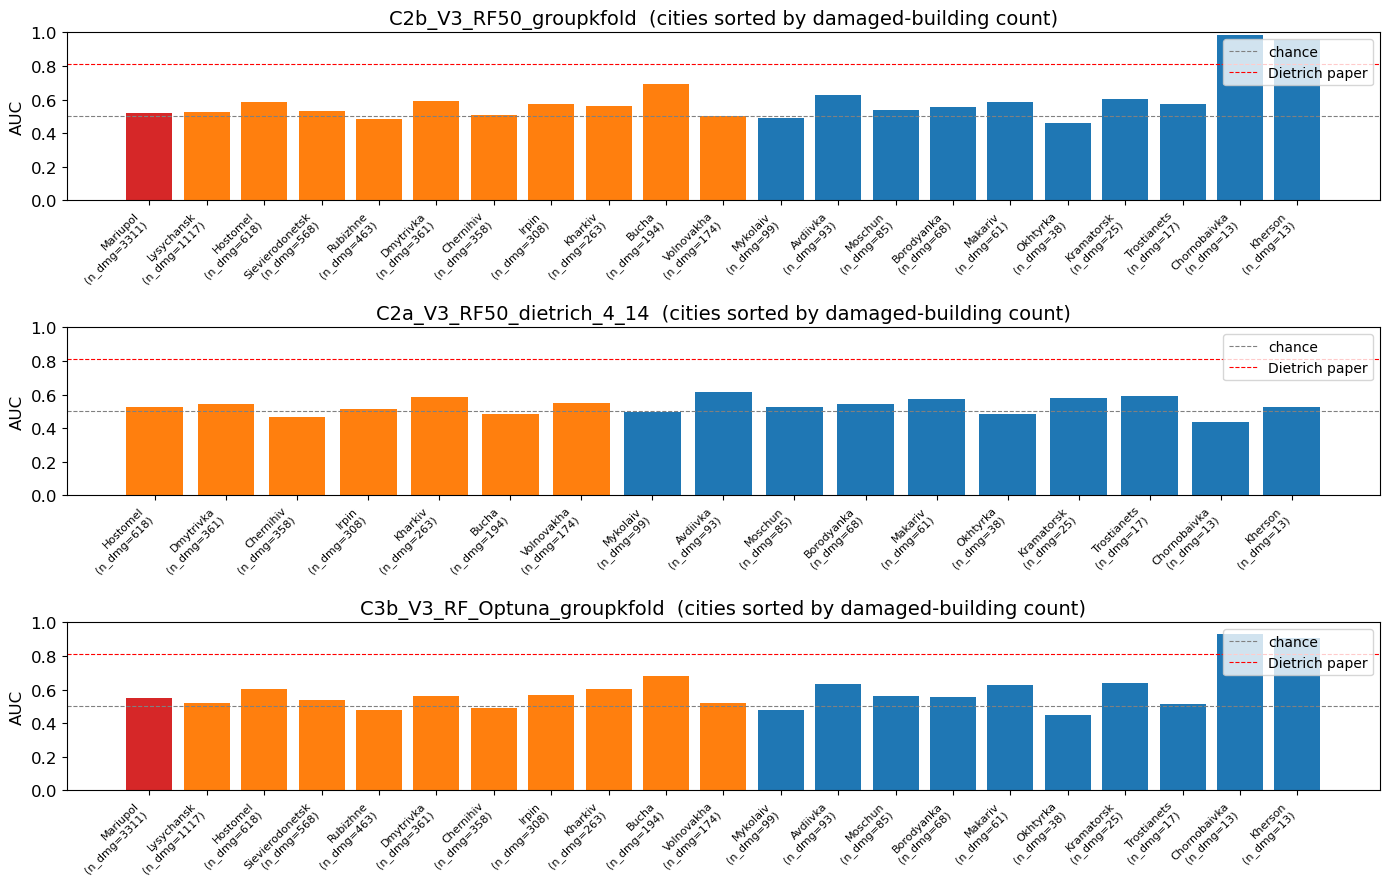

  Plot: cell_d1/per_city_auc_bars_20260510_211708.png


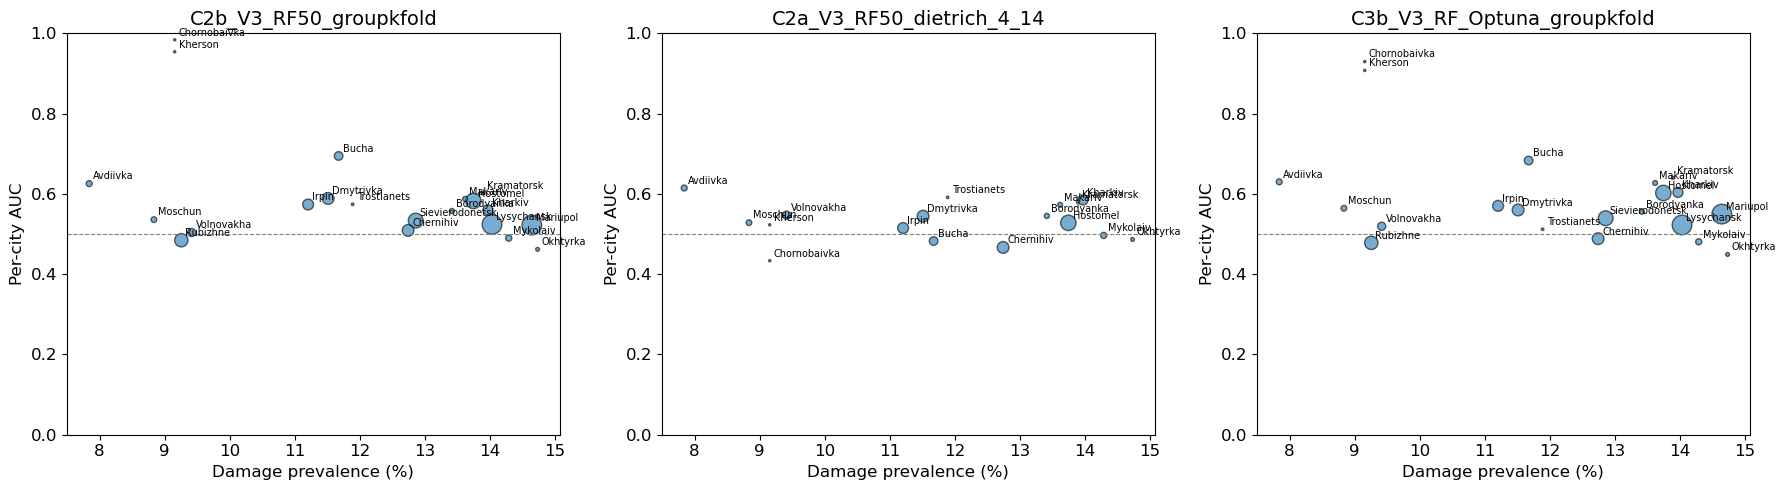

  Plot: cell_d1/auc_vs_prevalence_scatter_20260510_211709.png


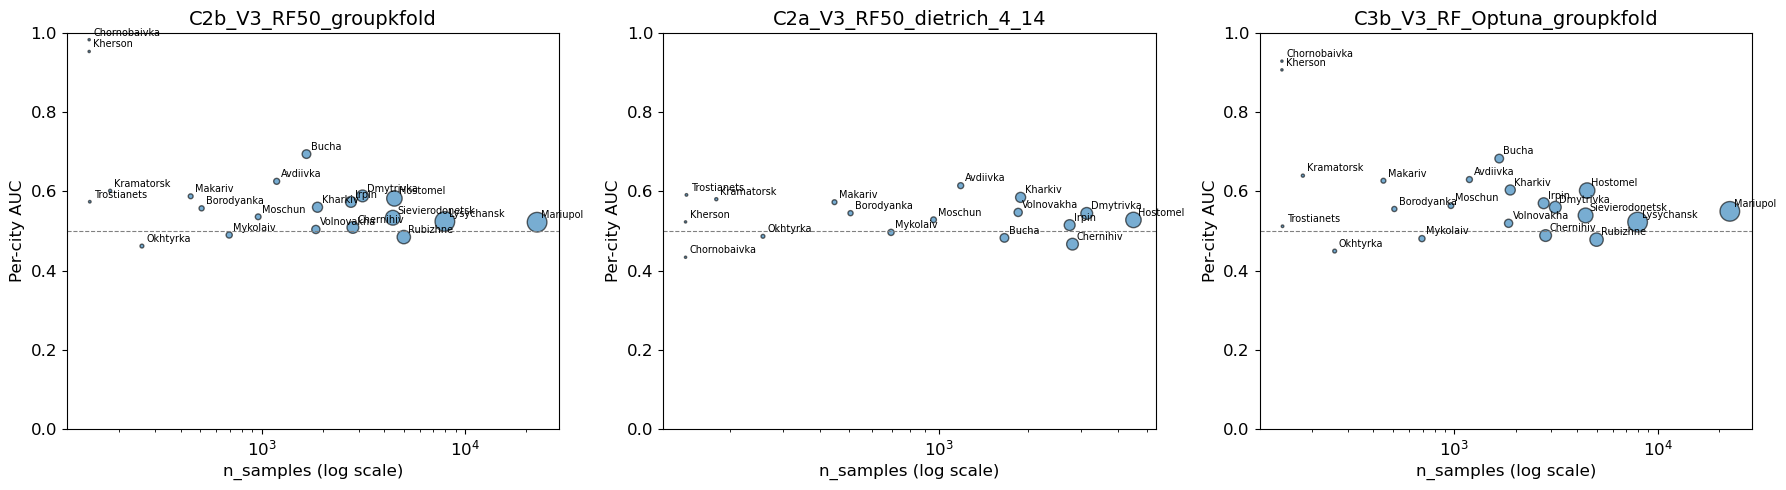

  Plot: cell_d1/auc_vs_n_samples_scatter_20260510_211710.png


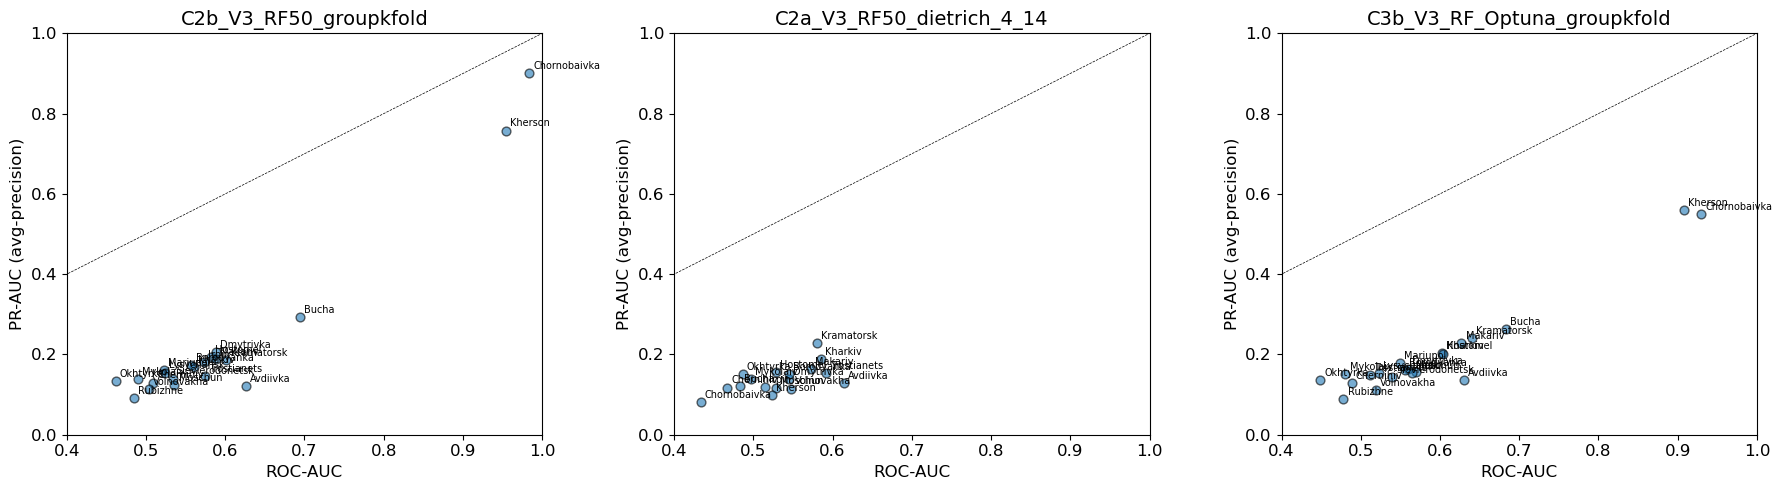

  Plot: cell_d1/roc_auc_vs_pr_auc_20260510_211711.png
  Saved: cell_d1/per_city_diagnostics_full_20260510_211711.csv (5.9 KB)

  C2b_V3_RF50_groupkfold:
    cities >= AUC 0.55: 12/21;  >= 0.60: 5;  >= 0.70: 2
    top-3 by AUC:
      Chornobaivka           AUC=0.984  PR-AUC=0.901  n_dmg=13  prev=9.2%
      Kherson                AUC=0.954  PR-AUC=0.758  n_dmg=13  prev=9.2%
      Bucha                  AUC=0.695  PR-AUC=0.293  n_dmg=194  prev=11.7%
  C2a_V3_RF50_dietrich_4_14:
    cities >= AUC 0.55: 5/17;  >= 0.60: 1;  >= 0.70: 0
    top-3 by AUC:
      Avdiivka               AUC=0.615  PR-AUC=0.129  n_dmg=93  prev=7.8%
      Trostianets            AUC=0.591  PR-AUC=0.154  n_dmg=17  prev=11.9%
      Kharkiv                AUC=0.585  PR-AUC=0.189  n_dmg=263  prev=14.0%
  C3b_V3_RF_Optuna_groupkfold:
    cities >= AUC 0.55: 12/21;  >= 0.60: 8;  >= 0.70: 2
    top-3 by AUC:
      Chornobaivka           AUC=0.930  PR-AUC=0.550  n_dmg=13  prev=9.2%
      Kherson                AUC=0.908  PR-

In [22]:
# @title CELL D1: PER-CITY DIAGNOSTICS (4 plots from existing OOFs)
# Uses C2_RESULTS / C3_RESULTS already in kernel. No retraining.
print("=" * 70)
print("CELL D1: PER-CITY DIAGNOSTICS")
print("=" * 70)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from datetime import datetime as _dt


def per_city_table(res):
    """Return a DataFrame with per-city AUC, PR-AUC, prevalence, n, n_damaged."""
    if res is None:
        return pd.DataFrame()
    rows = []
    yt = np.asarray(res['y_true'])
    yp = np.asarray(res['y_proba'])
    g  = np.asarray(res['groups'])
    for city in np.unique(g):
        m = (g == city)
        n = int(m.sum())
        n_pos = int(yt[m].sum())
        prev = n_pos / max(n, 1)
        if len(np.unique(yt[m])) < 2:
            auc = float('nan'); ap = float('nan')
        else:
            auc = roc_auc_score(yt[m], yp[m])
            ap  = average_precision_score(yt[m], yp[m])
        rows.append({'city': city, 'n': n, 'n_damaged': n_pos,
                     'prevalence': prev, 'auc': auc, 'pr_auc': ap})
    return pd.DataFrame(rows).sort_values('n_damaged', ascending=False).reset_index(drop=True)


# Build per-city tables for the most informative results
TABLES = {}
if 'C2_RESULTS' in dir() and '2b' in C2_RESULTS:
    TABLES['C2b_V3_RF50_groupkfold'] = per_city_table(C2_RESULTS['2b'])
if 'C2_RESULTS' in dir() and '2a' in C2_RESULTS:
    TABLES['C2a_V3_RF50_dietrich_4_14'] = per_city_table(C2_RESULTS['2a'])
if 'C3_RESULTS' in dir() and '3b' in C3_RESULTS:
    _r = C3_RESULTS['3b'].get('best_result') if isinstance(C3_RESULTS['3b'], dict) else C3_RESULTS['3b']
    TABLES['C3b_V3_RF_Optuna_groupkfold'] = per_city_table(_r)

print(f"  Tables built for: {list(TABLES.keys())}")

# --- Plot 1: per-city AUC bar chart (sorted by damaged count), one panel per result ---
n_panels = len(TABLES)
fig, axes = plt.subplots(n_panels, 1, figsize=(14, max(4, 3 * n_panels)), squeeze=False)
for ax, (name, tbl) in zip(axes[:, 0], TABLES.items()):
    if tbl.empty:
        ax.set_title(f"{name}: empty")
        continue
    colors = ['#d62728' if c == 'Mariupol' else ('#ff7f0e' if r['n_damaged'] >= 100 else '#1f77b4')
              for c, r in zip(tbl['city'], tbl.to_dict('records'))]
    ax.bar(range(len(tbl)), tbl['auc'], color=colors)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
    ax.axhline(0.813, color='red', linestyle='--', linewidth=0.8, label='Dietrich paper')
    ax.set_xticks(range(len(tbl)))
    ax.set_xticklabels([f"{c}\n(n_dmg={n})" for c, n in zip(tbl['city'], tbl['n_damaged'])],
                       rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel('AUC')
    ax.set_title(name + '  (cities sorted by damaged-building count)')
    ax.legend(loc='upper right')
plt.tight_layout()
save_fig(fig, 'per_city_auc_bars', 'cell_d1')

# --- Plot 2: AUC vs damage prevalence (scatter) ---
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), squeeze=False)
for ax, (name, tbl) in zip(axes[0, :], TABLES.items()):
    if tbl.empty: continue
    ax.scatter(tbl['prevalence'] * 100, tbl['auc'], s=tbl['n_damaged'].clip(10, 1000) / 5,
               alpha=0.6, edgecolor='k')
    for _, r in tbl.iterrows():
        ax.annotate(r['city'], (r['prevalence'] * 100, r['auc']), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Damage prevalence (%)')
    ax.set_ylabel('Per-city AUC')
    ax.set_title(name)
    ax.set_ylim(0.0, 1.0)
plt.tight_layout()
save_fig(fig, 'auc_vs_prevalence_scatter', 'cell_d1')

# --- Plot 3: AUC vs n_samples (scatter, log x) ---
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), squeeze=False)
for ax, (name, tbl) in zip(axes[0, :], TABLES.items()):
    if tbl.empty: continue
    ax.scatter(tbl['n'], tbl['auc'], s=tbl['n_damaged'].clip(10, 1000) / 5,
               alpha=0.6, edgecolor='k')
    for _, r in tbl.iterrows():
        ax.annotate(r['city'], (r['n'], r['auc']), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')
    ax.set_xscale('log')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('n_samples (log scale)')
    ax.set_ylabel('Per-city AUC')
    ax.set_title(name)
    ax.set_ylim(0.0, 1.0)
plt.tight_layout()
save_fig(fig, 'auc_vs_n_samples_scatter', 'cell_d1')

# --- Plot 4: side-by-side AUC vs PR-AUC (PR-AUC is the right metric under imbalance) ---
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), squeeze=False)
for ax, (name, tbl) in zip(axes[0, :], TABLES.items()):
    if tbl.empty: continue
    ax.scatter(tbl['auc'], tbl['pr_auc'], s=40, alpha=0.6, edgecolor='k')
    for _, r in tbl.iterrows():
        ax.annotate(r['city'], (r['auc'], r['pr_auc']), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.5)
    ax.set_xlim(0.4, 1.0); ax.set_ylim(0, 1.0)
    ax.set_xlabel('ROC-AUC'); ax.set_ylabel('PR-AUC (avg-precision)')
    ax.set_title(name)
plt.tight_layout()
save_fig(fig, 'roc_auc_vs_pr_auc', 'cell_d1')

# --- Save consolidated table ---
all_tbls = []
for name, tbl in TABLES.items():
    if tbl.empty: continue
    tbl2 = tbl.copy()
    tbl2['experiment'] = name
    all_tbls.append(tbl2)
if all_tbls:
    df_all = pd.concat(all_tbls, ignore_index=True)
    save_result(df_all, 'per_city_diagnostics_full', 'cell_d1', fmt='csv')

# --- Summary print ---
print()
for name, tbl in TABLES.items():
    if tbl.empty: continue
    above_055 = (tbl['auc'] >= 0.55).sum()
    above_060 = (tbl['auc'] >= 0.60).sum()
    above_070 = (tbl['auc'] >= 0.70).sum()
    print(f"  {name}:")
    print(f"    cities >= AUC 0.55: {above_055}/{len(tbl)};  >= 0.60: {above_060};  >= 0.70: {above_070}")
    top3 = tbl.nlargest(3, 'auc')[['city', 'auc', 'pr_auc', 'n_damaged', 'prevalence']]
    print(f"    top-3 by AUC:")
    for _, r in top3.iterrows():
        print(f"      {r['city']:<22s} AUC={r['auc']:.3f}  PR-AUC={r['pr_auc']:.3f}  "
              f"n_dmg={int(r['n_damaged'])}  prev={r['prevalence']*100:.1f}%")

CELL D2: UNIVARIATE FEATURE ROC-AUC ON V3 dietrich28
  load_v3('block_stats'): 63,243 rows, 334 cols, 21 cities
  V3 block_stats: 63,243 rows  /  262 dietrich28 cols
  After prepare_features: X=(63243, 262), y_pos_rate=13.04%

  Univariate AUC distribution across 262 features:
    median |AUC-0.5| = 0.0006
    max    |AUC|     = 0.5474  (best feature: s1__vh__blk_pre01__max)
    P95              = 0.5330
    features with |AUC| >= 0.55 : 0
    features with |AUC| >= 0.60 : 0
    features with |AUC| >= 0.65 : 0

  TOP-20 univariate features:
    + AUC=0.5474  (0.5474)  s1__vh__blk_pre01__max
    + AUC=0.5474  (0.5474)  s1__vh__baseline__max
    + AUC=0.5456  (0.5456)  s1__vh__blk01__max
    + AUC=0.5420  (0.5420)  s1__vh__blk_pre01__mean
    + AUC=0.5420  (0.5420)  s1__vh__baseline__mean
    + AUC=0.5416  (0.5416)  s1__vv__blk01__std
    + AUC=0.5408  (0.5408)  s1__vh__blk01__mean
    + AUC=0.5397  (0.5397)  s1__vh__blk_pre01__median
    + AUC=0.5397  (0.5397)  s1__vh__baseline__median


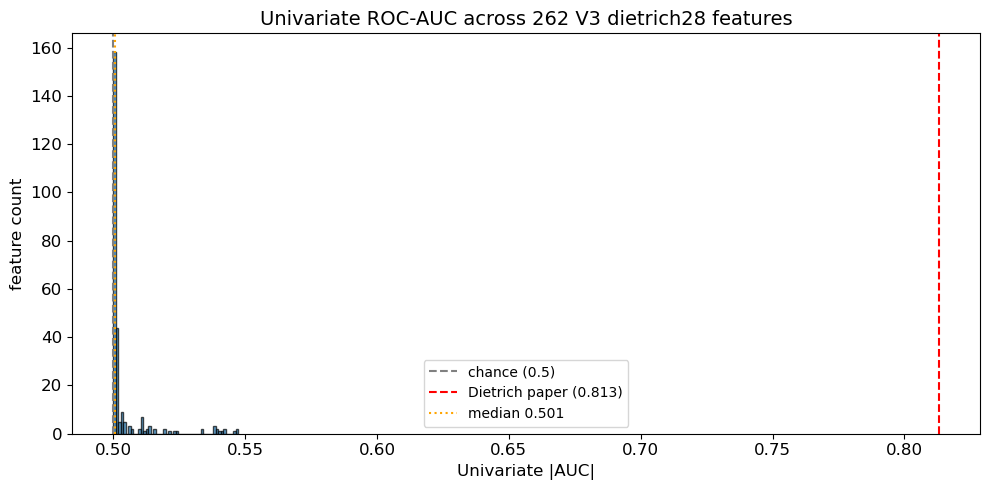

  Plot: cell_d2/univariate_auc_histogram_20260510_211715.png


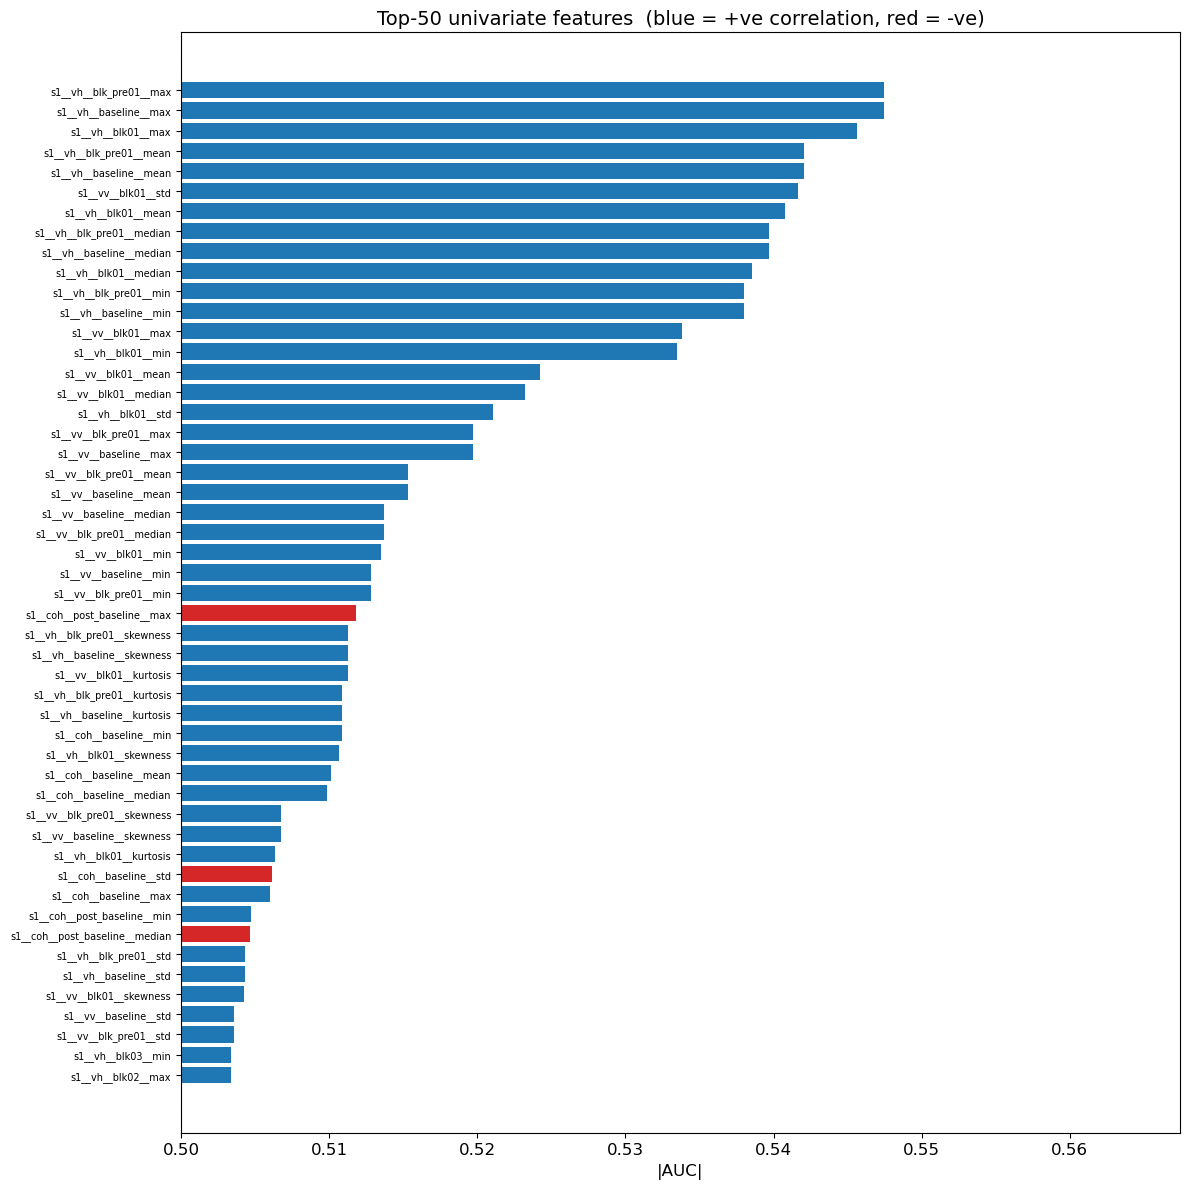

  Plot: cell_d2/univariate_auc_top50_20260510_211715.png
  Saved: cell_d2/univariate_feature_auc_v3_d28_20260510_211716.csv (17.3 KB)


58156

In [23]:
# @title CELL D2: UNIVARIATE FEATURE ROC-AUC ON V3 dietrich28
# Tests whether the dietrich28 feature space itself has signal vs damage_binary,
# independent of the RF classifier. Computes per-feature ROC-AUC (each feature
# used as a single-feature classifier with sign-flipping) on the 21-city pool.
# If the strongest single feature is at AUC 0.55-0.60, the feature space is
# the bottleneck (not the classifier or imbalance).
print("=" * 70)
print("CELL D2: UNIVARIATE FEATURE ROC-AUC ON V3 dietrich28")
print("=" * 70)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Reload V3 block_stats (cell C2 deleted df_v3 with gc.collect)
df_v3 = load_v3('block_stats')
d28_cols = filter_dietrich28(df_v3.columns.tolist())
print(f"  V3 block_stats: {len(df_v3):,} rows  /  {len(d28_cols)} dietrich28 cols")

prep = prepare_features(df_v3, d28_cols)
X, y, groups, sample_ids, feat_cols = prep
print(f"  After prepare_features: X={X.shape}, y_pos_rate={y.mean()*100:.2f}%")

# Per-feature univariate AUC: for each column, use it as a single-feature classifier.
# AUC < 0.5 means the feature is anti-correlated with damage; we report max(auc, 1-auc)
# so the ranking measures absolute discriminative power.
records = []
for j, col in enumerate(feat_cols):
    xj = X[:, j]
    if not np.isfinite(xj).any():
        continue
    valid = np.isfinite(xj)
    if valid.sum() < 100 or len(np.unique(y[valid])) < 2:
        continue
    try:
        a = roc_auc_score(y[valid], xj[valid])
    except Exception:
        continue
    a_abs = max(a, 1.0 - a)
    records.append({'feature': col, 'auc_signed': a, 'auc_abs': a_abs,
                    'sign': '+' if a >= 0.5 else '-',
                    'n_valid': int(valid.sum())})

df_uni = pd.DataFrame(records).sort_values('auc_abs', ascending=False).reset_index(drop=True)
print(f"\n  Univariate AUC distribution across {len(df_uni)} features:")
print(f"    median |AUC-0.5| = {(df_uni['auc_abs'] - 0.5).median():.4f}")
print(f"    max    |AUC|     = {df_uni['auc_abs'].max():.4f}  (best feature: {df_uni.iloc[0]['feature']})")
print(f"    P95              = {df_uni['auc_abs'].quantile(0.95):.4f}")
print(f"    features with |AUC| >= 0.55 : {(df_uni['auc_abs'] >= 0.55).sum()}")
print(f"    features with |AUC| >= 0.60 : {(df_uni['auc_abs'] >= 0.60).sum()}")
print(f"    features with |AUC| >= 0.65 : {(df_uni['auc_abs'] >= 0.65).sum()}")

print(f"\n  TOP-20 univariate features:")
for _, r in df_uni.head(20).iterrows():
    print(f"    {r['sign']} AUC={r['auc_abs']:.4f}  ({r['auc_signed']:.4f})  {r['feature']}")

print(f"\n  BOTTOM-20 univariate features (closest to chance):")
for _, r in df_uni.tail(20).iterrows():
    print(f"    {r['sign']} AUC={r['auc_abs']:.4f}  ({r['auc_signed']:.4f})  {r['feature']}")

# --- Plot: histogram of |AUC - 0.5| ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_uni['auc_abs'], bins=50, edgecolor='k', alpha=0.7)
ax.axvline(0.5, color='gray', linestyle='--', label='chance (0.5)')
ax.axvline(0.813, color='red', linestyle='--', label='Dietrich paper (0.813)')
ax.axvline(df_uni['auc_abs'].median(), color='orange', linestyle=':', label=f"median {df_uni['auc_abs'].median():.3f}")
ax.set_xlabel('Univariate |AUC|')
ax.set_ylabel('feature count')
ax.set_title(f'Univariate ROC-AUC across {len(df_uni)} V3 dietrich28 features')
ax.legend()
plt.tight_layout()
save_fig(fig, 'univariate_auc_histogram', 'cell_d2')

# --- Plot: top-50 bar ---
fig, ax = plt.subplots(figsize=(12, 12))
top50 = df_uni.head(50).iloc[::-1]  # reverse so best is at top
colors = ['#1f77b4' if s == '+' else '#d62728' for s in top50['sign']]
ax.barh(range(len(top50)), top50['auc_abs'], color=colors)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_yticks(range(len(top50)))
ax.set_yticklabels(top50['feature'], fontsize=7)
ax.set_xlabel('|AUC|')
ax.set_title('Top-50 univariate features  (blue = +ve correlation, red = -ve)')
ax.set_xlim(0.5, max(0.55, df_uni['auc_abs'].max() + 0.02))
plt.tight_layout()
save_fig(fig, 'univariate_auc_top50', 'cell_d2')

save_result(df_uni, 'univariate_feature_auc_v3_d28', 'cell_d2', fmt='csv')

del df_v3, prep, X, y, groups, sample_ids
import gc; gc.collect()

CELL D3: PR-AUC + THRESHOLD SWEEP
  Sources: ['C2b_V3_RF50_groupkfold', 'C2a_V3_RF50_dietrich_4_14', 'C3b_V3_RF_Optuna_groupkfold']

  C2b_V3_RF50_groupkfold:
    ROC-AUC = 0.5277
    PR-AUC  = 0.1468  (baseline = prevalence = 13.04%)
    F1@default(0.5)            = 0.0077
    Best F1                    = 0.2309 at threshold 0.04
    @best F1: precision=0.1305  recall=0.9984  TP=8234.0  FN=13.0  FP=54853.0
  Saved: cell_d3/threshold_sweep__C2b_V3_RF50_groupkfold_20260510_211717.csv (4.4 KB)

  C2a_V3_RF50_dietrich_4_14:
    ROC-AUC = 0.5277
    PR-AUC  = 0.1327  (baseline = prevalence = 11.99%)
    F1@default(0.5)            = 0.0098
    Best F1                    = 0.2147 at threshold 0.08
    @best F1: precision=0.1207  recall=0.9706  TP=2706.0  FN=82.0  FP=19717.0
  Saved: cell_d3/threshold_sweep__C2a_V3_RF50_dietrich_4_14_20260510_211718.csv (4.5 KB)

  C3b_V3_RF_Optuna_groupkfold:
    ROC-AUC = 0.5372
    PR-AUC  = 0.1466  (baseline = prevalence = 13.04%)
    F1@default(0.5)     

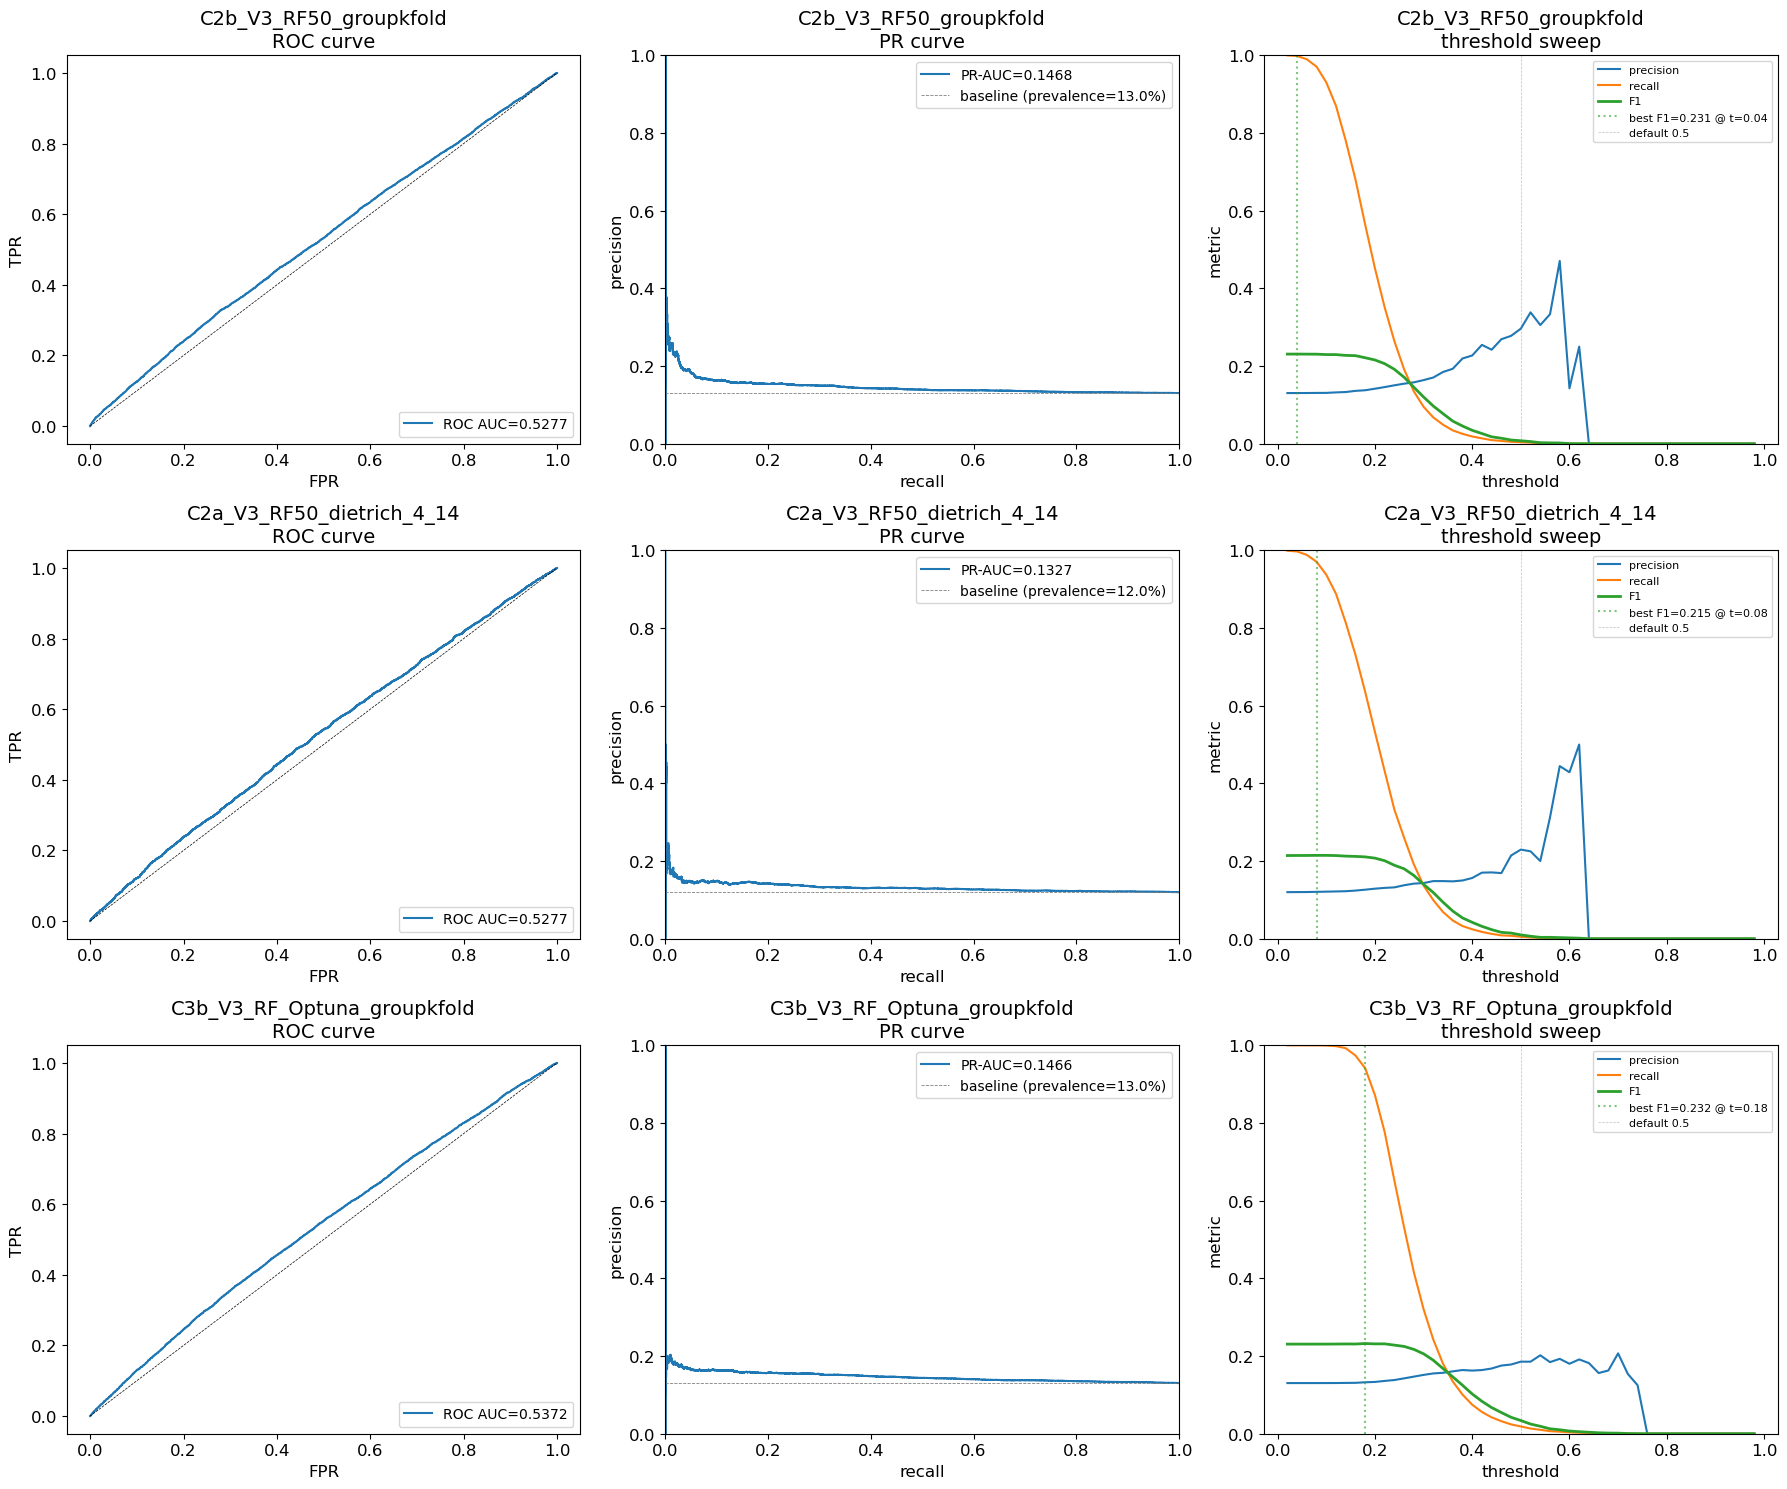

  Plot: cell_d3/roc_pr_threshold_sweep_grid_20260510_211719.png
  Saved: cell_d3/pr_threshold_summary_20260510_211720.csv (0.6 KB)


In [24]:
# @title CELL D3: PR-AUC + THRESHOLD SWEEP (no retraining)
# Replots C2_RESULTS / C3_RESULTS OOF probabilities under PR-AUC and a full
# threshold sweep. Under 12% prevalence, ROC-AUC over-states quality and F1@0.5
# under-states it. This cell finds the best F1 threshold and reports it.
print("=" * 70)
print("CELL D3: PR-AUC + THRESHOLD SWEEP")
print("=" * 70)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                              average_precision_score, f1_score, precision_score,
                              recall_score)


def threshold_sweep(yt, yp, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.02, 0.99, 0.02)
    rows = []
    for t in thresholds:
        pred = (yp >= t).astype(int)
        rows.append({'threshold': t,
                     'precision': precision_score(yt, pred, zero_division=0),
                     'recall':    recall_score(yt, pred, zero_division=0),
                     'f1':        f1_score(yt, pred, zero_division=0),
                     'tp': int(((pred == 1) & (yt == 1)).sum()),
                     'fn': int(((pred == 0) & (yt == 1)).sum()),
                     'fp': int(((pred == 1) & (yt == 0)).sum()),
                     'tn': int(((pred == 0) & (yt == 0)).sum())})
    return pd.DataFrame(rows)


SOURCES = []
if 'C2_RESULTS' in dir() and '2b' in C2_RESULTS:
    SOURCES.append(('C2b_V3_RF50_groupkfold', C2_RESULTS['2b']))
if 'C2_RESULTS' in dir() and '2a' in C2_RESULTS:
    SOURCES.append(('C2a_V3_RF50_dietrich_4_14', C2_RESULTS['2a']))
if 'C3_RESULTS' in dir() and '3b' in C3_RESULTS:
    _r = C3_RESULTS['3b'].get('best_result') if isinstance(C3_RESULTS['3b'], dict) else C3_RESULTS['3b']
    SOURCES.append(('C3b_V3_RF_Optuna_groupkfold', _r))

print(f"  Sources: {[s[0] for s in SOURCES]}")

all_summaries = []
fig, axes = plt.subplots(len(SOURCES), 3, figsize=(18, 5 * len(SOURCES)), squeeze=False)

for row_i, (name, res) in enumerate(SOURCES):
    yt = np.asarray(res['y_true']); yp = np.asarray(res['y_proba'])
    auc_roc = roc_auc_score(yt, yp)
    auc_pr  = average_precision_score(yt, yp)
    prev    = yt.mean()

    # --- ROC curve ---
    fpr, tpr, _ = roc_curve(yt, yp)
    ax = axes[row_i, 0]
    ax.plot(fpr, tpr, label=f'ROC AUC={auc_roc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.5)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{name}\nROC curve')
    ax.legend(loc='lower right')

    # --- PR curve ---
    pre, rec, thr_pr = precision_recall_curve(yt, yp)
    ax = axes[row_i, 1]
    ax.plot(rec, pre, label=f'PR-AUC={auc_pr:.4f}')
    ax.axhline(prev, color='gray', linestyle='--', linewidth=0.6,
               label=f'baseline (prevalence={prev*100:.1f}%)')
    ax.set_xlabel('recall'); ax.set_ylabel('precision')
    ax.set_ylim(0, 1.0); ax.set_xlim(0, 1.0)
    ax.set_title(f'{name}\nPR curve')
    ax.legend(loc='upper right')

    # --- threshold sweep ---
    sw = threshold_sweep(yt, yp)
    ax = axes[row_i, 2]
    ax.plot(sw['threshold'], sw['precision'], label='precision', color='#1f77b4')
    ax.plot(sw['threshold'], sw['recall'],    label='recall',    color='#ff7f0e')
    ax.plot(sw['threshold'], sw['f1'],        label='F1',        color='#2ca02c', linewidth=2)
    best_row = sw.loc[sw['f1'].idxmax()]
    ax.axvline(best_row['threshold'], color='#2ca02c', linestyle=':', alpha=0.6,
               label=f"best F1={best_row['f1']:.3f} @ t={best_row['threshold']:.2f}")
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='default 0.5')
    ax.set_xlabel('threshold'); ax.set_ylabel('metric')
    ax.set_title(f'{name}\nthreshold sweep')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(0, 1.0)

    print(f"\n  {name}:")
    print(f"    ROC-AUC = {auc_roc:.4f}")
    print(f"    PR-AUC  = {auc_pr:.4f}  (baseline = prevalence = {prev*100:.2f}%)")
    print(f"    F1@default(0.5)            = {f1_score(yt, (yp >= 0.5).astype(int), zero_division=0):.4f}")
    print(f"    Best F1                    = {best_row['f1']:.4f} at threshold {best_row['threshold']:.2f}")
    print(f"    @best F1: precision={best_row['precision']:.4f}  recall={best_row['recall']:.4f}  "
          f"TP={best_row['tp']}  FN={best_row['fn']}  FP={best_row['fp']}")

    all_summaries.append({
        'experiment': name, 'roc_auc': auc_roc, 'pr_auc': auc_pr, 'prevalence': prev,
        'f1_default_0.5': f1_score(yt, (yp >= 0.5).astype(int), zero_division=0),
        'best_threshold': best_row['threshold'], 'best_f1': best_row['f1'],
        'best_precision': best_row['precision'], 'best_recall': best_row['recall'],
    })
    sw['experiment'] = name
    save_result(sw, f'threshold_sweep__{name}', 'cell_d3', fmt='csv')

plt.tight_layout()
save_fig(fig, 'roc_pr_threshold_sweep_grid', 'cell_d3')

if all_summaries:
    save_result(pd.DataFrame(all_summaries), 'pr_threshold_summary', 'cell_d3', fmt='csv')

CELL D4: MARIUPOL-ONLY DIAGNOSTIC
  load_v3('block_stats'): 63,243 rows, 334 cols, 21 cities
  Loaded V3 dietrich28: X=(63243, 262), prevalence=13.04%
  Mariupol mask: 22,615 samples, 3,311 damaged (14.64% prevalence)
    fold 1: ROC-AUC=0.6836  PR-AUC=0.2766  F1@0.5=0.0847  n_test=4523  n_test_pos=663
    fold 2: ROC-AUC=0.6789  PR-AUC=0.2694  F1@0.5=0.0723  n_test=4523  n_test_pos=662
    fold 3: ROC-AUC=0.6835  PR-AUC=0.2839  F1@0.5=0.1015  n_test=4523  n_test_pos=662
    fold 4: ROC-AUC=0.6596  PR-AUC=0.2548  F1@0.5=0.0660  n_test=4523  n_test_pos=662
    fold 5: ROC-AUC=0.6677  PR-AUC=0.2597  F1@0.5=0.0764  n_test=4523  n_test_pos=662

  --- Mariupol within-city stratified-5fold OOF ---
    pooled OOF ROC-AUC = 0.6746  (mean fold = 0.6747 +/- 0.0095)
    pooled OOF PR-AUC  = 0.2673   (mean fold = 0.2689)
    mean fold F1@0.5   = 0.0802

  --- Mariupol slice of C2b cross-city OOF (model trained on OTHER cities) ---
    Mariupol C2b ROC-AUC = 0.5222
    Mariupol C2b PR-AUC  = 0.1607

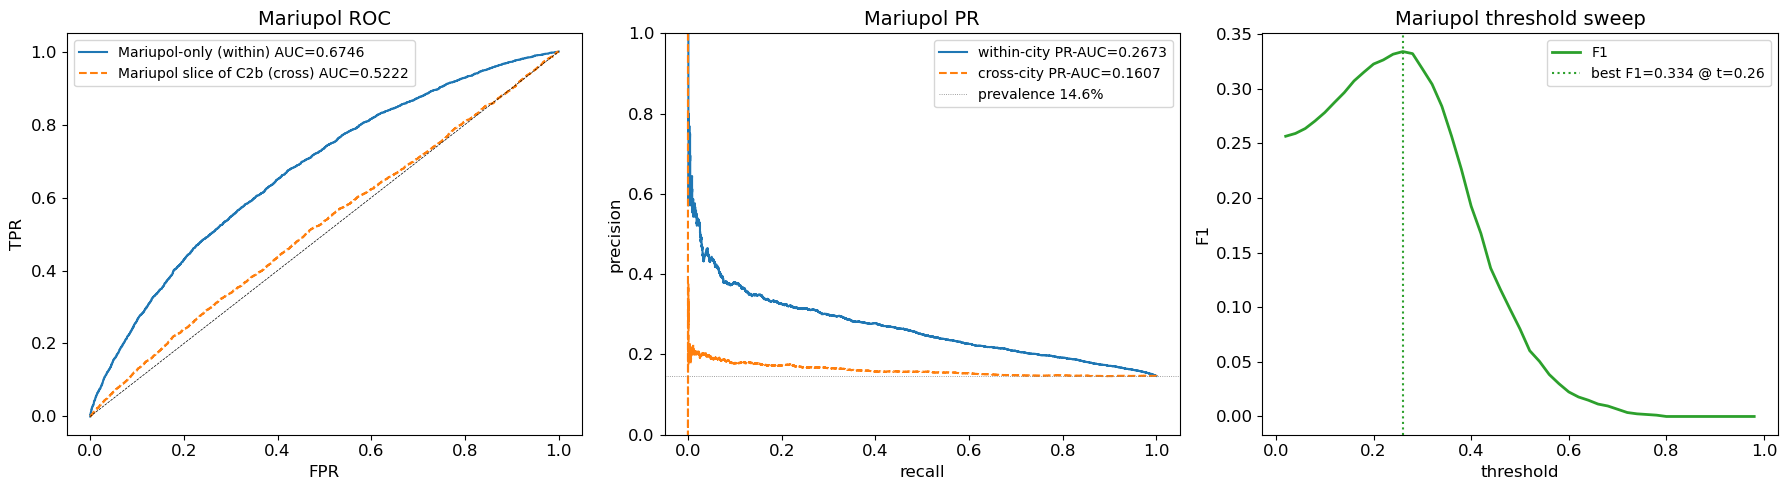

  Plot: cell_d4/mariupol_only_diagnostics_20260510_211725.png


19123

In [25]:
# @title CELL D4: MARIUPOL-ONLY DIAGNOSTIC (transfer-floor test)
# Trains the same RF_DIETRICH_PARAMS on Mariupol V3 dietrich28 with a stratified
# 80/20 building-level split, evaluates on the held-out 20%. Compares to:
#   (a) C2b's pooled GroupKFold AUC (0.568) and
#   (b) the per-Mariupol AUC pulled from C2b OOF.
# Logic:
#   - If Mariupol-only AUC >> 0.58, the features carry signal in dense-damage
#     cities and the cross-city gap is a transfer / label-sparsity problem.
#   - If Mariupol-only AUC ~ 0.58, the features themselves are weak even where
#     damage is dense -> the dietrich28 reconstruction is the bottleneck.
print("=" * 70)
print("CELL D4: MARIUPOL-ONLY DIAGNOSTIC")
print("=" * 70)

import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import matplotlib.pyplot as plt
import gc

MARIUPOL_CITY_NAME = 'Mariupol'

# Reload V3 (deleted by C2)
df_v3 = load_v3('block_stats')
d28_cols = filter_dietrich28(df_v3.columns.tolist())
prep = prepare_features(df_v3, d28_cols)
X_all, y_all, groups_all, sample_ids, feat_cols = prep
print(f"  Loaded V3 dietrich28: X={X_all.shape}, prevalence={y_all.mean()*100:.2f}%")

mask_m = (np.asarray(groups_all) == MARIUPOL_CITY_NAME)
print(f"  Mariupol mask: {mask_m.sum():,} samples, "
      f"{int(y_all[mask_m].sum()):,} damaged ({y_all[mask_m].mean()*100:.2f}% prevalence)")

if mask_m.sum() < 200:
    print(f"  SKIP: insufficient Mariupol samples")
else:
    Xm = X_all[mask_m]; ym = y_all[mask_m]

    # 5-fold stratified within Mariupol (NOT GroupKFold -- we want building-level signal,
    # the ceiling under perfect city-internal training)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_aucs, fold_prs, fold_f1s = [], [], []
    yt_oof = np.zeros_like(ym, dtype=float); yp_oof = np.zeros_like(ym, dtype=float)
    for fi, (tr, te) in enumerate(skf.split(Xm, ym)):
        clf = RandomForestClassifier(**RF_DIETRICH_PARAMS)
        clf.fit(Xm[tr], ym[tr])
        proba = clf.predict_proba(Xm[te])[:, 1]
        a = roc_auc_score(ym[te], proba) if len(np.unique(ym[te])) > 1 else float('nan')
        ap = average_precision_score(ym[te], proba)
        pred = (proba >= 0.5).astype(int)
        f = f1_score(ym[te], pred, zero_division=0)
        fold_aucs.append(a); fold_prs.append(ap); fold_f1s.append(f)
        yt_oof[te] = ym[te]; yp_oof[te] = proba
        print(f"    fold {fi+1}: ROC-AUC={a:.4f}  PR-AUC={ap:.4f}  F1@0.5={f:.4f}  "
              f"n_test={te.size}  n_test_pos={int(ym[te].sum())}")

    auc_pooled = roc_auc_score(yt_oof, yp_oof)
    pr_pooled  = average_precision_score(yt_oof, yp_oof)
    print(f"\n  --- Mariupol within-city stratified-5fold OOF ---")
    print(f"    pooled OOF ROC-AUC = {auc_pooled:.4f}  (mean fold = {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f})")
    print(f"    pooled OOF PR-AUC  = {pr_pooled:.4f}   (mean fold = {np.mean(fold_prs):.4f})")
    print(f"    mean fold F1@0.5   = {np.mean(fold_f1s):.4f}")

    # --- Compare to Mariupol slice of C2b OOF ---
    if 'C2_RESULTS' in dir() and '2b' in C2_RESULTS:
        r2b = C2_RESULTS['2b']
        m2b = (np.asarray(r2b['groups']) == MARIUPOL_CITY_NAME)
        if m2b.sum() > 0:
            yt_c2b = np.asarray(r2b['y_true'])[m2b]
            yp_c2b = np.asarray(r2b['y_proba'])[m2b]
            if len(np.unique(yt_c2b)) > 1:
                auc_c2b = roc_auc_score(yt_c2b, yp_c2b)
                pr_c2b  = average_precision_score(yt_c2b, yp_c2b)
                print(f"\n  --- Mariupol slice of C2b cross-city OOF (model trained on OTHER cities) ---")
                print(f"    Mariupol C2b ROC-AUC = {auc_c2b:.4f}")
                print(f"    Mariupol C2b PR-AUC  = {pr_c2b:.4f}")
                print(f"\n  TRANSFER GAP (within-Mariupol  -  cross-to-Mariupol) = {auc_pooled - auc_c2b:+.4f}")

    # --- Save result + log to registry ---
    res = {
        'experiment': 'D4_Mariupol_within_5fold',
        'auc_groupkfold': auc_pooled, 'auc_3x3_max': auc_pooled,
        'auc_pr': pr_pooled,
        'fold_aucs': fold_aucs, 'auc_mean': float(np.mean(fold_aucs)), 'auc_std': float(np.std(fold_aucs)),
        'f1_groupkfold': float(np.mean(fold_f1s)),
        'n_features': Xm.shape[1], 'n_buildings': int(mask_m.sum()),
        'n_cities': 1,
        'y_true': yt_oof, 'y_proba': yp_oof,
        'groups': np.full(mask_m.sum(), MARIUPOL_CITY_NAME),
        'point_id': np.asarray(sample_ids)[mask_m],
        'fold_id': np.zeros(mask_m.sum(), dtype=int),
        'split': 'mariupol_stratified_5fold',
    }
    log_result(res, cell_id='D4', parquet_name='V3_block_stats',
               feature_set_name='dietrich28', feature_cols=feat_cols,
               classifier_name='RF-50-paper', classifier_params=RF_DIETRICH_PARAMS,
               cv_method='stratified_5fold_mariupol_only',
               note='D4 Mariupol-only within-city ceiling (transfer-floor test)')
    save_oof_from_result(res, 'D4_Mariupol_within_5fold', OUT_DIR / 'cell_d4', is_final=False)

    # --- Plot: pooled-OOF ROC + PR + threshold sweep for Mariupol-only ---
    from sklearn.metrics import roc_curve, precision_recall_curve
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fpr, tpr, _ = roc_curve(yt_oof, yp_oof)
    axes[0].plot(fpr, tpr, label=f'Mariupol-only (within) AUC={auc_pooled:.4f}')
    if 'r2b' in dir() and m2b.sum() > 0 and len(np.unique(yt_c2b)) > 1:
        fpr2, tpr2, _ = roc_curve(yt_c2b, yp_c2b)
        axes[0].plot(fpr2, tpr2, label=f'Mariupol slice of C2b (cross) AUC={auc_c2b:.4f}', linestyle='--')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.5)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('Mariupol ROC'); axes[0].legend()

    pre, rec, _ = precision_recall_curve(yt_oof, yp_oof)
    axes[1].plot(rec, pre, label=f'within-city PR-AUC={pr_pooled:.4f}')
    if 'r2b' in dir() and m2b.sum() > 0 and len(np.unique(yt_c2b)) > 1:
        pre2, rec2, _ = precision_recall_curve(yt_c2b, yp_c2b)
        axes[1].plot(rec2, pre2, label=f'cross-city PR-AUC={pr_c2b:.4f}', linestyle='--')
    axes[1].axhline(ym.mean(), color='gray', linestyle=':', linewidth=0.6,
                    label=f'prevalence {ym.mean()*100:.1f}%')
    axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision')
    axes[1].set_title('Mariupol PR'); axes[1].legend(); axes[1].set_ylim(0, 1)

    thrs = np.arange(0.02, 0.99, 0.02)
    f1s = [f1_score(yt_oof, (yp_oof >= t).astype(int), zero_division=0) for t in thrs]
    axes[2].plot(thrs, f1s, label='F1', color='#2ca02c', linewidth=2)
    best_t = thrs[int(np.argmax(f1s))]; best_f = max(f1s)
    axes[2].axvline(best_t, linestyle=':', color='#2ca02c',
                    label=f'best F1={best_f:.3f} @ t={best_t:.2f}')
    axes[2].set_xlabel('threshold'); axes[2].set_ylabel('F1')
    axes[2].set_title('Mariupol threshold sweep'); axes[2].legend()
    plt.tight_layout()
    save_fig(fig, 'mariupol_only_diagnostics', 'cell_d4')

del df_v3, prep, X_all, y_all, groups_all, sample_ids
gc.collect()

# CELL C7: PER-CITY AUC DISTRIBUTION + BOOTSTRAP LEAKAGE CI

Diagnostic-only cell. No new training. Two outputs:

1. Per-city AUC for each cell C2-C6 result, plotted as a boxplot (NOT mean).
2. Bootstrap confidence intervals (1000 iterations) for the leakage delta C2a-C2b and C3a-C3b. If the CI excludes zero, leakage is statistically significant.


CELL C7: PER-CITY AUC + BOOTSTRAP LEAKAGE CI
  C7 source cells available: ['C2', 'C3']
  Saved: cell_c7/per_city_auc_all_cells_20260510_192423.csv (3.8 KB)


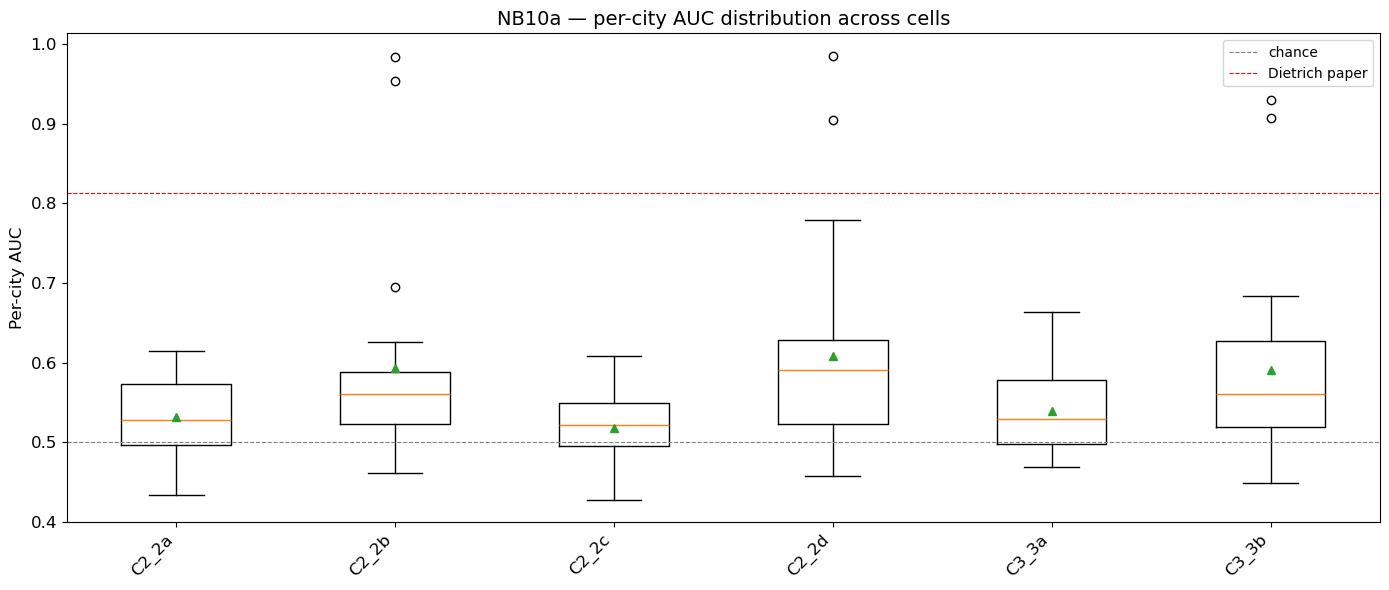

  Plot: cell_c7/per_city_auc_boxplot_20260510_192424.png
  Untuned leakage delta (2a - 2b): mean=-0.0000  CI=[-0.0141, +0.0134]  prob_one_sided=0.497
  Tuned leakage delta (3a - 3b):   mean=-0.0039  CI=[-0.0177, +0.0094]  prob_one_sided=0.717


In [13]:
# @title CELL C7: PER-CITY AUC DISTRIBUTION + BOOTSTRAP LEAKAGE CI
print("=" * 70)
print("CELL C7: PER-CITY AUC + BOOTSTRAP LEAKAGE CI")
print("=" * 70)

# --- Per-city AUC for every saved result ---
def per_city_auc(res):
    if res is None: return {}
    out = {}
    for city in np.unique(res['groups']):
        m = res['groups'] == city
        if len(np.unique(res['y_true'][m])) > 1:
            out[city] = roc_auc_score(res['y_true'][m], res['y_proba'][m])
    return out

per_city_records = []
# Build the (cell_label, results_dict) list dynamically so cells C4..C6 that
# have not yet been defined are silently skipped (instead of NameError).
_cell_sources = []
if 'C2_RESULTS' in dir():
    _cell_sources.append(('C2', C2_RESULTS))
if 'C3_RESULTS' in dir():
    _cell_sources.append(('C3', {k: v['best_result'] if isinstance(v, dict) and 'best_result' in v else v
                                  for k, v in C3_RESULTS.items()}))
if 'C4_RESULTS' in dir():
    _cell_sources.append(('C4', {k: v['best_result'] if isinstance(v, dict) and 'best_result' in v else v
                                  for k, v in C4_RESULTS.items()}))
if 'C5_RESULTS' in dir():
    _cell_sources.append(('C5', {k: v['best_result'] if isinstance(v, dict) and 'best_result' in v else v
                                  for k, v in C5_RESULTS.items()}))
if 'C6_RESULTS' in dir():
    _cell_sources.append(('C6', {k: v['best_result'] if isinstance(v, dict) and 'best_result' in v else v
                                  for k, v in C6_RESULTS.items()}))
print(f"  C7 source cells available: {[lab for lab, _ in _cell_sources]}")
for cell_label, results_dict in _cell_sources:
    for sub, res in results_dict.items():
        for city, auc_c in per_city_auc(res).items():
            per_city_records.append({'cell': cell_label, 'sub': sub, 'city': city, 'auc': auc_c})

if per_city_records:
    df_pc = pd.DataFrame(per_city_records)
    save_result(df_pc, 'per_city_auc_all_cells', 'cell_c7', fmt='csv')

    # Boxplot: one box per (cell, sub)
    fig, ax = plt.subplots(figsize=(14, 6))
    df_pc['label'] = df_pc['cell'] + '_' + df_pc['sub'].astype(str)
    labels = df_pc['label'].unique().tolist()
    data = [df_pc[df_pc['label'] == lab]['auc'].values for lab in labels]
    ax.boxplot(data, labels=labels, vert=True, showmeans=True)
    ax.set_ylabel('Per-city AUC')
    ax.set_title('NB10a — per-city AUC distribution across cells')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
    ax.axhline(0.813, color='red', linestyle='--', linewidth=0.8, label='Dietrich paper')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    save_fig(fig, 'per_city_auc_boxplot', 'cell_c7')
else:
    print("  No per-city records to plot")

# --- Bootstrap leakage CI ---
def bootstrap_auc_diff(res_a, res_b, n_iter=1000, seed=42):
    """Bootstrap-CI for AUC(a) - AUC(b). Both must have y_true / y_proba arrays."""
    if res_a is None or res_b is None: return None
    rng = np.random.RandomState(seed)
    deltas = []
    n_a, n_b = len(res_a['y_true']), len(res_b['y_true'])
    for _ in range(n_iter):
        idx_a = rng.randint(0, n_a, n_a)
        idx_b = rng.randint(0, n_b, n_b)
        try:
            auc_a = roc_auc_score(res_a['y_true'][idx_a], res_a['y_proba'][idx_a])
            auc_b = roc_auc_score(res_b['y_true'][idx_b], res_b['y_proba'][idx_b])
            deltas.append(auc_a - auc_b)
        except Exception:
            continue
    if not deltas: return None
    deltas = np.array(deltas)
    return {'mean': deltas.mean(), 'ci_lo': np.percentile(deltas, 2.5),
            'ci_hi': np.percentile(deltas, 97.5),
            'p_excludes_zero': (deltas > 0).mean() if deltas.mean() > 0 else (deltas < 0).mean()}

# C2a vs C2b (untuned leakage delta)
if '2a' in C2_RESULTS and '2b' in C2_RESULTS:
    ci_untuned = bootstrap_auc_diff(C2_RESULTS['2a'], C2_RESULTS['2b'], n_iter=1000)
    if ci_untuned:
        print(f"  Untuned leakage delta (2a - 2b): mean={ci_untuned['mean']:+.4f}  "
              f"CI=[{ci_untuned['ci_lo']:+.4f}, {ci_untuned['ci_hi']:+.4f}]  "
              f"prob_one_sided={ci_untuned['p_excludes_zero']:.3f}")

# C3a vs C3b (tuned leakage delta)
if '3a' in C3_RESULTS and '3b' in C3_RESULTS:
    ci_tuned = bootstrap_auc_diff(
        C3_RESULTS['3a']['best_result'],
        C3_RESULTS['3b']['best_result'],
        n_iter=1000,
    )
    if ci_tuned:
        print(f"  Tuned leakage delta (3a - 3b):   mean={ci_tuned['mean']:+.4f}  "
              f"CI=[{ci_tuned['ci_lo']:+.4f}, {ci_tuned['ci_hi']:+.4f}]  "
              f"prob_one_sided={ci_tuned['p_excludes_zero']:.3f}")

# CELL C8: SAVE CONSOLIDATED OOF + EXPERIMENT SUMMARY

Final cell. Saves the experiment-summary CSV and the registry. All OOFs were already saved per cell during C2-C6; this cell consolidates the headline numbers in one place for NB12 ingestion.


In [15]:
# @title CELL C8: SAVE CONSOLIDATED OOF + SUMMARY
print("=" * 70)
print("CELL C8: SAVE CONSOLIDATED OOF + EXPERIMENT SUMMARY")
print("=" * 70)
# Build a flat summary across all C2-C6 results
summary_rows = []
def _add_row(cell, sub, res, classifier='', n_trials=None, params=None):
    if res is None: return
    auc = res.get('auc_3x3_max', res.get('auc_groupkfold', float('nan')))
    summary_rows.append({
        'cell': cell, 'sub': sub, 'experiment': res.get('experiment', ''),
        'classifier': classifier, 'n_trials': n_trials,
        'auc': auc, 'split': res.get('split', 'GroupKFold'),
        'n_features': res.get('n_features'), 'n_samples': res.get('n_buildings'),
        'best_params': str(params) if params is not None else '',
    })
# Guard each C*_RESULTS loop so cells not yet defined are silently skipped
# (instead of NameError). C2 and C3 will be processed; C4 / C5 / C6 are
# only appended once those cells have been added and run.
if 'C2_RESULTS' in dir():
    for sub, res in C2_RESULTS.items():
        _add_row('C2', sub, res, classifier='RF-50-paper')
if 'C3_RESULTS' in dir():
    for sub, opt in C3_RESULTS.items():
        _res = opt['best_result'] if isinstance(opt, dict) and 'best_result' in opt else opt
        _add_row('C3', sub, _res, classifier='RF-Optuna',
                 n_trials=opt.get('n_trials') if isinstance(opt, dict) else None,
                 params=opt.get('best_params') if isinstance(opt, dict) else None)
if 'C4_RESULTS' in dir():
    for sub, opt in C4_RESULTS.items():
        _res = opt['best_result'] if isinstance(opt, dict) and 'best_result' in opt else opt
        _add_row('C4', sub, _res, classifier=f"{sub}-Optuna",
                 n_trials=opt.get('n_trials') if isinstance(opt, dict) else None,
                 params=opt.get('best_params') if isinstance(opt, dict) else None)
if 'C5_RESULTS' in dir():
    for sub, opt in C5_RESULTS.items():
        _res = opt['best_result'] if isinstance(opt, dict) and 'best_result' in opt else opt
        _add_row('C5', sub, _res, classifier=f"{opt.get('classifier_name', '') if isinstance(opt, dict) else ''}-Optuna",
                 n_trials=opt.get('n_trials') if isinstance(opt, dict) else None,
                 params=opt.get('best_params') if isinstance(opt, dict) else None)
if 'C6_RESULTS' in dir():
    for sub, opt in C6_RESULTS.items():
        _res = opt['best_result'] if isinstance(opt, dict) and 'best_result' in opt else opt
        _add_row('C6', sub, _res, classifier=f"{opt.get('classifier_name', '') if isinstance(opt, dict) else ''}-Optuna",
                 n_trials=opt.get('n_trials') if isinstance(opt, dict) else None,
                 params=opt.get('best_params') if isinstance(opt, dict) else None)
print(f"  C8 source cells available: {[c for c in ['C2','C3','C4','C5','C6'] if c+'_RESULTS' in dir()]}")
if summary_rows:
    df_sum = pd.DataFrame(summary_rows)
    df_sum = df_sum.sort_values('auc', ascending=False).reset_index(drop=True)
    save_result(df_sum, 'NB10a_experiment_summary', 'cell_c8', fmt='csv')
    print("\n  CONSOLIDATED RESULTS (sorted by AUC, descending):")
    print("  " + "=" * 78)
    print(f"  {'rank':<5}{'cell':<6}{'sub':<5}{'classifier':<22}{'AUC':>8}{'feat':>7}{'samples':>10}")
    print("  " + "-" * 78)
    for i, row in df_sum.head(20).iterrows():
        nfeat = row['n_features'] if row['n_features'] is not None else 'NA'
        print(f"  {i+1:<5}{row['cell']:<6}{row['sub']:<5}{row['classifier']:<22}"
              f"{row['auc']:>8.4f}{str(nfeat):>7}{row['n_samples']:>10}")
# Save registry
import datetime as _dt
registry_path = registry.save()
print(f"\n  Registry saved: {registry_path}")
print(f"\n  All OOFs in: {OUT_DIR}")
print(f"  Total experiments registered: {len(EXPERIMENT_LOG)}")
print("\n  NB10a complete.")

CELL C8: SAVE CONSOLIDATED OOF + EXPERIMENT SUMMARY
  C8 source cells available: ['C2', 'C3']
  Saved: cell_c8/NB10a_experiment_summary_20260510_193114.csv (0.9 KB)

  CONSOLIDATED RESULTS (sorted by AUC, descending):
  rank cell  sub  classifier                 AUC   feat   samples
  ------------------------------------------------------------------------------
  1    C3    3b   RF-Optuna               0.5814    262     63243
  2    C3    3a   RF-Optuna               0.5722    262     23246
  3    C2    2b   RF-50-paper             0.5683    262     63243
  4    C2    2a   RF-50-paper             0.5576    262     23246
  5    C2    2d   RF-50-paper             0.5461   2096     63243
  6    C2    2c   RF-50-paper             0.5281   2096     23246
  SAVED: NB10a_v1_experiments_20260507_234428.json (6 experiments)
  SAVED: NB10a_v1_experiments_20260507_234428.csv

  Registry saved: /content/drive_f/masterthesis/results/registry

  All OOFs in: /content/drive_f/masterthesis/data/outpu